# Normalizing-flow phase-space tests

Focused extract of the normalizing-flow (NF) experiments from `Hamiltonian_flow_PhaseSpace.ipynb`, kept small (outputs stripped) so it is easy to edit and extend.

**Run the two setup cells first** (imports + shared constants: `sim`, `h_true`, `t_obs`, `z0_sigma`, `w0_sigma`, `sz_eq`). They are lightweight (no simulation runs there) but every test below depends on them. Then run any test independently.

Contents: **Test 4** (data → flow → Hamiltonian flow → true $f_0$) · **Test 5** (when does the flow help?) · **Test 9** (flow *as* $f_0$, joint with $h$) · **Test 10** / **10c** (flexible NF $f_0$ vs biased Gaussian; bias sweep) · **Test 11** (non-Gaussian $f_0$).


In [1]:
from phase_space_simulation import (
    Widmark1DSimulation,
    Widmark1DAnalysis,
    fit_h_pc_dm_mle_fast,
    plot_phase_space_hist,
)
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


In [2]:
# ==========================================================
# Shared constants (sampling / evolution / fitting moved to Cell 3 loop)
# ==========================================================
import math as _m
h_true = 250.0
t_obs = 400.0  # Myr

sim = Widmark1DSimulation(h_pc_dm=h_true)
ana = Widmark1DAnalysis(sim)

# Initial distribution f0 (what the likelihood assumes) -- now placed at VERTICAL
# EQUILIBRIUM in the Gaussian / harmonic approximation: sigma_z is LOCKED to
# sigma_w by the potential,  sigma_z = sigma_w / nu ,  nu = sqrt(4 pi G rho_tot(0))
# (vertical period ~80 Myr).  Previously z0_sigma = 10 pc, i.e. ~26x too thin --
# a cold midplane sheet FAR out of equilibrium.  This near-equilibrium Gaussian
# still breathes ~12% against the ANHARMONIC potential, and that anharmonic
# phase-mixing (no satellite involved) is what makes the realistic spiral seen
# in the mean-subtraction (df/dt != 0) plot.
w0_sigma = 20.0
_nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick + sim.rho0_gas + sim.rho_DM))
z0_sigma = w0_sigma / _nu          # ~259 pc for sigma_w = 20 km/s
def sz_eq(sw):                     # equilibrium sigma_z for ANY sigma_w (sigma_z = sigma_w / nu)
    return sw / _nu
print(f"equilibrium IC: sigma_w = {w0_sigma:.0f} km/s -> sigma_z = {z0_sigma:.1f} pc "
      f"(nu = {_nu:.4f} (km/s)/pc, vertical period {2*_m.pi/_nu/sim.MYR_TO_TUNIT:.0f} Myr)")


equilibrium IC: sigma_w = 20 km/s -> sigma_z = 259.4 pc (nu = 0.0771 (km/s)/pc, vertical period 80 Myr)


# Test 9 — Optimize the normalizing flow and the Hamiltonian flow **together**

**Hypothesis (user).** Training the flow *separately* just re-encodes the data into a smoothed estimate that is "something it is not", so the downstream fit can only do worse. The flow might only help if the flow and the Hamiltonian fit are minimized **jointly**.

**Joint, done right.** The principled fusion is to let the flow *be* the initial DF $f_0$ (not a separate fit to the observed snapshot), and maximize the exact data likelihood
$$\mathcal L(\phi, h) = \sum_i \log f_{0,\phi}\big(T_h(x_i)\big)$$
over the flow parameters $\phi$ **and** $h_{\rm dm}$ at the same time (Liouville: $|\det \partial T_h/\partial x| = 1$, so no Jacobian term). Now there is a single objective and both "flows" move together.

**What happens (pre-run 2026-07-20).**
* **Part A** — the joint fit *does* recover $h\approx250$ (ties the Gaussian MLE of Test 3b at $-0.2\%$; it does **not** beat it), for inits on either side.
* **Part B** — the *profile likelihood* explains why this is a knife-edge, not a win. For a **Gaussian** $f_0$ the well in $h$ is deep (~1.3 nats); for a **flexible** $f_0$ (flow / kNN-entropy of the back-integrated cloud) it is nearly **flat** (~0.15 nats). Reason: the back-integration $T_h$ is a symplectic (Hamiltonian) map, so it **conserves phase-space entropy** (Liouville) — a maximally flexible density sees almost the same "compactness" at every $h$, so it carries almost no constraint on $h$.

**Conclusion.** The joint fit only recovered $h$ because the small flow's *finite capacity* accidentally regularizes it toward Gaussian-like behavior (make the flow bigger and the init-spread widens, 3→8 pc). All the real constraint on $h$ comes from **assuming $f_0$ is simple** — the flow's flexibility works *against* that. Joint optimization ties the plain Gaussian MLE at best, at ~50× the cost and with a 9× shallower likelihood; it cannot beat it. The user's ranking is right (joint > separate NF), but the ceiling is still the direct MLE.

⏱ ≈ 1.5 min.

In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 9 -- flow AS the initial DF f0, optimized JOINTLY with h_dm by max
#   likelihood: L(phi,h) = sum_i log f0_flow(T_h(x_i)).  Plus the profile
#   likelihood (Gaussian f0 vs flexible f0) that explains the result.
#   Reuses Test 3b clean data if present.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
from scipy.special import digamma
from scipy.spatial import cKDTree
from math import lgamma
import fitter as _fitter
importlib.reload(_fitter)
from fitter import ZWNormalizingFlow, torch_back_integrate

# ---- clean data (single Gaussian, evolved, NO satellite) ----
try:
    z_obs9, w_obs9 = z_obs3b, w_obs3b
    print("Reusing Test 3b clean data.")
except NameError:
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    z_obs9, w_obs9 = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

def _backint(h, z, w, ns=2000):
    with torch.no_grad():
        zb, wb = torch_back_integrate(torch.tensor(z), torch.tensor(w), t_obs,
                                      torch.tensor(float(h)), sim, n_steps=ns)
    return zb.numpy(), wb.numpy()

# ---- PART A: joint (flow=f0) + h maximum likelihood ----
def _joint_flow_h(h_init, n_epochs=250, ns=1000, n_sub=500, seed=0):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    flow = ZWNormalizingFlow(n_couplings=8, hidden=64).double()
    z0i, w0i = _backint(h_init, z_obs9, w_obs9, ns)
    flow.set_standardization(z0i, w0i)
    h = torch.nn.Parameter(torch.tensor(float(h_init), dtype=torch.float64))
    opt = torch.optim.Adam([{'params': flow.parameters(), 'lr': 1e-3},
                            {'params': [h], 'lr': 2.0}])
    hist = []
    for ep in range(n_epochs):
        idx = rng.choice(z_obs9.size, size=n_sub, replace=False)
        zb, wb = torch_back_integrate(torch.tensor(z_obs9[idx]), torch.tensor(w_obs9[idx]),
                                      t_obs, h, sim, n_steps=ns)
        loss = -flow.log_prob(zb, wb).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_([h], max_norm=50.0); opt.step()
        with torch.no_grad(): h.clamp_(50, 800)
        hist.append(h.item())
    return h.item(), hist

t0 = _t.time()
print("\nPART A -- flow(=f0) and h optimized TOGETHER by max-likelihood:")
jointA = {}
for hi in [180, 350]:
    hf, hist = _joint_flow_h(hi); jointA[hi] = hist
    print(f"  init h={hi} -> joint h_fit={hf:6.1f}  ({(hf-h_true)/h_true*100:+.1f}%)")

# ---- PART B: profile likelihood vs h, Gaussian f0 vs flexible f0 ----
# NLL floor achievable by a density model = differential entropy of the
# back-integrated cloud.  Gaussian f0 -> 0.5 ln((2 pi e)^2 det Cov); flexible
# f0 -> kNN (Kozachenko-Leonenko) entropy.  Fixed (z,w) scaling for a fair shape.
zc, wc = _backint(h_true, z_obs9, w_obs9); SZ, SW = zc.std(), wc.std()
def _knnH(X, k=5):
    N, d = X.shape
    dist, _ = cKDTree(X).query(X, k=k+1)
    c_d = np.pi**(d/2) / np.exp(lgamma(d/2 + 1))
    return digamma(N) - digamma(k) + np.log(c_d) + (d/N)*np.sum(np.log(dist[:, k] + 1e-12))

hgridP = np.array([150, 175, 200, 225, 240, 250, 260, 275, 300, 325, 350, 400], float)
flex, gau = [], []
for h in hgridP:
    zb, wb = _backint(h, z_obs9, w_obs9)
    X = np.stack([zb/SZ, wb/SW], axis=1)
    flex.append(_knnH(X))
    C = np.cov(X.T); gau.append(0.5*np.log((2*np.pi*np.e)**2 * np.linalg.det(C)))
flex = np.array(flex) - np.min(flex); gau = np.array(gau) - np.min(gau)
print(f"\nPART B -- profile-likelihood well depth (max-min over h):")
print(f"  Gaussian f0 : {gau.max():.2f} nats  (min at h={hgridP[gau.argmin()]:.0f})  -> SHARP well")
print(f"  flexible f0 : {flex.max():.2f} nats  (min at h={hgridP[flex.argmin()]:.0f})  -> ~FLAT (Liouville)")
print(f"  flexible is {gau.max()/max(flex.max(),1e-6):.0f}x flatter -> ~no constraint on h")
print(f"total {(_t.time()-t0)/60:.1f} min")

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for hi, hist in jointA.items():
    ax.plot(hist, label=f'init {hi}')
ax.axhline(h_true, color='k', ls='--', label='truth 250')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$h_{\rm dm}$ [pc]')
ax.set_title('Part A: joint (flow=$f_0$) + h recovers ~250\n(ties the Gaussian MLE; does not beat it)')
ax.legend()

ax = axes[1]
ax.plot(hgridP, gau,  'o-', color='C0', label=f'Gaussian $f_0$  (well {gau.max():.2f} nats)')
ax.plot(hgridP, flex, 's-', color='C3', label=f'flexible $f_0$ / flow  (well {flex.max():.2f} nats)')
ax.axvline(h_true, color='k', ls='--')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'profile NLL $-$ min [nats]')
ax.set_title('Part B: why -- flexible $f_0$ likelihood is ~flat in h\n'
             '(Liouville: symplectic flow conserves phase-space entropy)')
ax.legend()
plt.tight_layout(); plt.show()

# Test 10 — Can a **flexible NF $f_0$ (+ time-dep NN potential)** recover $h$ under a wrong PDF? (vs a static biased $f_0$)

*(Replaces the old "does a biased PDF bias h" test.)* Motivation: in reality $f_0$ is unknown, so one might hope a **flexible normalizing-flow $f_0$** (Test 9 style: the flow *is* $f_0$, fit jointly with $h$) avoids the bias of assuming a wrong parametric $f_0$ — and that a **time-dependent NN potential** $\delta\Phi(z,t)$ could mop up whatever is left. This test checks that hope, head-to-head with a rigid (even biased) Gaussian $f_0$. Clean data: single-Gaussian truth, static $h=250$, **no satellite**.

**Part A — bias & NN compensation (N=2000).** Recover $h$ from two inits (180, 350) for: static Gaussian $f_0$ pinned at a **wrong** $\sigma_w$; the same **+ NN**; a flexible **NF** $f_0$; and **NF + NN**.

**Part B — the decisive metric: constraint strength.** The init-*spread* (how much the answer depends on where you started) measures how tightly $h$ is pinned. Swept vs data size $N$ for a rigid Gaussian vs small/large flows.

**Result (pre-run 2026-07-20).**
* The **rigid** Gaussian pins $h$ to **±1 pc regardless of $N$** — if its assumed params are wrong it is slightly *biased* (e.g. $\sigma_w$ 20× off → $h\approx246$), but always **definite**.
* The **flexible NF** trades that bias for a **collapsing constraint**: init-spread grows $1\to3\to8$ pc (N=2000, small→big flow) and $1\to12\to23$ pc at N=500. More capacity or less data ⇒ worse. This is the Liouville flat-likelihood degeneracy (Test 9) made concrete.
* The **NN does not compensate** a biased pdf: on the static biased $f_0$ it stayed idle from one init and **destabilised** $h$ from the other (246 → 297).

**Takeaway.** You cannot robustly recover $h$ by *relaxing* $f_0$ (flow) and bolting on a NN potential — the constraint on $h$ fundamentally comes from *restricting* $f_0$, and flexibility destroys it while the NN can't rebuild it. This dead-end is what pushes us to a **different objective function** (not snapshot-likelihood — e.g. a CBE / $\partial f/\partial t$ residual).

⏱ ≈ 10 min.

In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 10 -- flexible NF f0 (+ time-dep NN potential) vs static (biased)
#   Gaussian f0, for recovering h.  Stationary potential, NO satellite.
#   Part A: bias + NN-compensation table (N=2000).
#   Part B: constraint strength (init-spread) vs data size N.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_freegaussian_nn_mle, fit_h_flow_f0_joint_mle

SZ_T, SW_T = z0_sigma, w0_sigma
t0 = _t.time()

def _data(N, seed=7):
    z0, w0 = sim.sample_near_midplane(N=N, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=seed)
    Zs, Ws, _ = sim.evolve_record(z0, w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
    return Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

def _static(zo, wo, sw_fit, use_nn, h_init, ep=150):
    r = fit_h_freegaussian_nn_mle(sim, zo, wo, t_obs, z0_sigma=SZ_T, w0_sigma=SW_T,
        mu_z_init=0., mu_w_init=0., z0_sigma_fit_init=SZ_T, w0_sigma_fit_init=sw_fit,
        h_init=h_init, use_nn_correction=use_nn, time_dependent_nn=True, use_satellite=False,
        fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
        nn_frac_bound=0.10, nn_hidden=8, lr_nn=1e-2, lr_A=5e-2,
        n_epochs=ep, n_sub=500, n_steps=2000, h_bounds=(20., 3000.), seed=42, verbose=False)
    return r['h_pc_dm_fitted'], (r['nn_frac_achieved'] or 0.0)

def _nf(zo, wo, h_init, nc=8, hid=64, use_nn=False, ep=200):
    r = fit_h_flow_f0_joint_mle(sim, zo, wo, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=nc, flow_hidden=hid, n_epochs=ep, n_sub=min(500, zo.size),
        n_steps=1000, seed=0, verbose=False)
    return r['h_pc_dm_fitted'], (r['nn_frac_achieved'] or 0.0)

# ---------- PART A: bias + NN compensation, N=2000, biased sigma_w (ratio 20) ----------
zA, wA = _data(2000)
SW_BIASED = 1.0    # true 20 -> ratio 20 (a real, stable pdf bias)
print(f"PART A -- recover h=250 from inits (180,350); static f0 biased at sigma_w={SW_BIASED} "
      f"(true {SW_T:.0f}, ratio {SW_T/SW_BIASED:.0f}):")
print(f"{'method':28s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
rowsA = []
for tag, fn in [
    ("static biased Gauss f0", lambda hi: _static(zA, wA, SW_BIASED, False, hi)),
    ("static biased + NN",     lambda hi: _static(zA, wA, SW_BIASED, True,  hi)),
    ("flexible NF f0",         lambda hi: _nf(zA, wA, hi, use_nn=False)),
    ("flexible NF f0 + NN",    lambda hi: _nf(zA, wA, hi, use_nn=True)),
]:
    (h1, f1), (h2, f2) = fn(180), fn(350)
    rowsA.append((tag, h1, h2, abs(h1-h2), 100*max(f1, f2)))
    print(f"{tag:28s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {100*max(f1,f2):6.2f}  "
          f"({_t.time()-t0:.0f}s)", flush=True)

# ---------- PART B: constraint strength (init-spread) vs data size ----------
print(f"\nPART B -- init-spread (|h(180)-h(350)|) vs N; rigid Gaussian (true sigma) vs flows:")
Ns = [2000, 500, 200]
methods = [("static Gaussian (rigid)", lambda zo, wo, hi: _static(zo, wo, SW_T, False, hi)),
           ("NF f0 small (8x64)",      lambda zo, wo, hi: _nf(zo, wo, hi, 8, 64)),
           ("NF f0 big (16x128)",      lambda zo, wo, hi: _nf(zo, wo, hi, 16, 128))]
spread = {m[0]: [] for m in methods}
for N in Ns:
    zo, wo = _data(N)
    for name, fn in methods:
        h1, h2 = fn(zo, wo, 180)[0], fn(zo, wo, 350)[0]
        spread[name].append(abs(h1 - h2))
    print(f"  N={N:4d}: " + " | ".join(f"{m[0].split()[0]}...={spread[m[0]][-1]:5.1f}pc" for m in methods)
          + f"   ({_t.time()-t0:.0f}s)", flush=True)
print(f"total {(_t.time()-t0)/60:.1f} min")

# ---------- plots ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
x = np.arange(len(rowsA))
ax.bar(x - 0.2, [r[1] for r in rowsA], 0.4, label='from init 180')
ax.bar(x + 0.2, [r[2] for r in rowsA], 0.4, label='from init 350')
ax.axhline(h_true, color='k', ls='--', label='truth 250')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rowsA], rotation=20, ha='right', fontsize=8)
ax.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
ax.set_title('Part A: NN cannot compensate a biased pdf;\nNF trades bias for init-dependence')
ax.legend(fontsize=8)

ax = axes[1]
for name, _ in methods:
    ax.plot(Ns, spread[name], 'o-', label=name)
ax.set_xscale('log'); ax.set_xlabel('data size N'); ax.set_ylabel(r'init-spread $|h_{180}-h_{350}|$ [pc]')
ax.set_title('Part B: constraint strength\nrigid f0 stays ~1 pc; flexible NF collapses')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [ ]:
# ============================================================================
# TEST 10 -- NLL(h) profile for the FLEXIBLE NF f0 (NOT the 10c sweep, NOT the
#   rigid Gaussian).  Draws the likelihood curve the joint fit minimises and marks
#   where the free-h fit lands, so we can see whether the fit sits at the curve's
#   min.  Two variants: NF only, and NF + time-dep NN potential.
#   Because the flow IS f0, the profile point at a FROZEN h means: retrain the
#   flow (+NN) with h held fixed, then NLL(h) = -<log f0(backint(x_obs; h))> on the
#   full cloud (symplectic map, det=1).  h is frozen via lr_h=0.  ~8 min.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

# --- setup guard: bootstrap sim + shared constants if the top cells were not run ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma
except NameError:
    from phase_space_simulation import Widmark1DSimulation
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0*_m.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
    z0_sigma = w0_sigma/_nu
SZ_T, SW_T = z0_sigma, w0_sigma

# reuse Test 10 data (single-Gaussian truth, static h_true, no satellite) or regen
try:
    zA, wA
except NameError:
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zA, wA = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

EP, NS, NSUB = 100, 800, 500
def _nf(h_init, use_nn, ep, lr_h):
    return fit_h_flow_f0_joint_mle(sim, zA, wA, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=NSUB, n_steps=NS,
        lr_h=lr_h, seed=0, verbose=False)

def _prof_nll(h, use_nn):                 # NLL at FROZEN h: train flow(+NN), eval on full cloud
    r = _nf(h, use_nn, EP, 0.0)
    A = torch.tensor(r['A_nn']) if r['A_nn'] is not None else None
    with torch.no_grad():
        zb, wb = torch_back_integrate(torch.tensor(zA), torch.tensor(wA), t_obs,
            torch.tensor(float(h)), sim, n_steps=NS, nn_model=r['nn_model'], A_nn=A,
            use_nn_correction=use_nn, time_dependent_nn=True)
        return -r['flow'].log_prob(zb, wb).mean().item()

t0 = _t.time()
h_grid = np.linspace(130, 400, 11)
prof, ends = {}, {}
for use_nn, tag in [(False, "NF only"), (True, "NF + NN")]:
    prof[tag] = np.array([_prof_nll(h, use_nn) for h in h_grid])
    ends[tag] = (_nf(180., use_nn, 150, 2.0)['h_pc_dm_fitted'],
                 _nf(350., use_nn, 150, 2.0)['h_pc_dm_fitted'])
    print(f"{tag}: profile min h={h_grid[prof[tag].argmin()]:.0f} depth={prof[tag].max()-prof[tag].min():.3f} nats"
          f" | free-h fit 180->{ends[tag][0]:.0f} 350->{ends[tag][1]:.0f}  ({_t.time()-t0:.0f}s)", flush=True)

base = min(prof['NF only'].min(), prof['NF + NN'].min())
fig, ax = plt.subplots(figsize=(8.2, 5.2))
for tag, col in [("NF only", "C0"), ("NF + NN", "C2")]:
    ax.plot(h_grid, prof[tag]-base, 'o-', color=col, label=f'NLL($h$) {tag}')
    e1, e2 = ends[tag]
    ax.axvline(e1, color=col, ls='--', lw=1); ax.axvline(e2, color=col, ls=':', lw=1)
    ax.annotate(f'{tag} fit\n180$\\to${e1:.0f}\n350$\\to${e2:.0f}',
                (e2, (prof[tag]-base).max()*0.6), color=col, fontsize=7, ha='left')
ax.axvline(h_true, color='k', lw=1, alpha=.5, label='truth 250')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'NLL $-$ min [nats]')
ax.set_title('Test 10: flexible-NF NLL($h$) profile (h frozen, flow retrained at each h)\n'
             'shallow single well ~250; the NN does not deepen it and widens the init-spread')
ax.legend(fontsize=8, loc='upper center')
plt.tight_layout(); plt.show()
print(f"total {(_t.time()-t0)/60:.1f} min")


In [ ]:
# ============================================================================
# TEST 10 -- NF NLL(h) PROFILE (reproducible).  The negative log-likelihood of the
#   normalizing flow vs h_dm with ALL bijective coupling layers left at their
#   minimum: at each frozen h the flow is retrained (h fixed, lr_h=0) and NLL(h) is
#   the flow's -<log f0(backint(x_obs; h))> on the full cloud.  This is the genuine
#   profile likelihood of the NF.  NF-only: the static (rigid) Gaussian f0 is NOT
#   run (slow, no new info), and no NN.  ~1.5 min.
# ============================================================================
import time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

EP, NS, NSUB = 100, 800, 500
h_grid = np.linspace(130, 400, 11)

def nf_nll_profile(z_obs, w_obs):
    """NLL(h) with the flow (all bijective coupling layers) retrained to its
    MINIMUM at each frozen h (h held fixed via lr_h=0).  NLL(h) is then the
    flow's -<log f0(backint(x_obs; h))> on the FULL cloud (symplectic, det=1)."""
    out = np.empty_like(h_grid); t0 = _t.time()
    for i, h in enumerate(h_grid):
        r = fit_h_flow_f0_joint_mle(sim, z_obs, w_obs, t_obs, h_init=float(h),
            use_nn_correction=False, n_couplings=8, flow_hidden=64,
            n_epochs=EP, n_sub=NSUB, n_steps=NS, lr_h=0.0, seed=0, verbose=False)
        with torch.no_grad():
            zb, wb = torch_back_integrate(torch.tensor(z_obs), torch.tensor(w_obs),
                t_obs, torch.tensor(float(h)), sim, n_steps=NS)
            out[i] = -r['flow'].log_prob(zb, wb).mean().item()
        print(f"  h={h:6.1f}  NLL={out[i]:.4f}  ({_t.time()-t0:.0f}s)", flush=True)
    return out

def plot_nf_nll_profile(nll, test_label, color, savepath):
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.plot(h_grid, nll - nll.min(), 'o-', color=color, lw=1.8, label='NF NLL($h$)')
    ax.axvline(h_true, color='k', lw=1, alpha=.5, label='truth 250')
    ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'NF NLL $-$ min [nats]')
    ax.set_title(f'{test_label} -- NF NLL($h$) profile '
                 '(flow retrained to its min at each $h$)\n'
                 f'well depth {nll.max()-nll.min():.3f} nats over $h\\in$[130,400]')
    ax.legend(fontsize=8); ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(savepath, dpi=140); plt.show()
    print(f"profile min at h={h_grid[nll.argmin()]:.0f}, "
          f"depth={nll.max()-nll.min():.4f} nats -> {savepath}")

# this test's data (regenerate the baseline single-Gaussian cloud if the Test 10
# cell above was not run in this session)
try:
    zA, wA
except NameError:
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=z0_sigma,
                                        w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000,
                                    n_snaps=10, seed=0, use_satellite=False,
                                    h_pc_dm=h_true)
    zA, wA = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
nll10 = nf_nll_profile(zA, wA)
plot_nf_nll_profile(nll10, 'Baseline Gaussian $f_0$', 'C0',
                    'plots/nf_nll_profile_gaussian_f0.png')


# Test 10c — Bias sweep: fitted $h_{\rm dm}$ vs $\sigma_w$ pdf-mismatch, for all four $f_0$ models

*(Extends Test 10 Part A, which used a single mismatch ratio of 20.)* Here we sweep the **pdf bias** — the ratio $r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$ between the true velocity dispersion and the one the fit assumes — over a wide range, and read off the recovered $h_{\rm dm}$ for each of the four $f_0$ models:

1. **static biased Gaussian $f_0$** — $\sigma_w$ pinned at the (wrong) fitted value;
2. **static biased Gaussian $f_0$ + NN** — same, plus a 10%-capped time-dependent NN potential;
3. **flexible NF $f_0$** — a normalizing flow *is* $f_0$, fit jointly with $h$;
4. **flexible NF $f_0$ + NN** — the flow plus the same NN potential.

**Why the NF curves are flat.** The two *static* models literally contain a $\sigma_w$ knob, so they feel the mismatch directly. The two *NF* models learn $f_0$ from the data and have **no $\sigma_w$ assumption at all** — so their recovered $h$ is, by construction, independent of $r$. We therefore compute each NF model once (over inits × seeds) and draw it as a **horizontal reference band**; the spread of that band is the NF's own (init/seed) uncertainty — the Liouville flat-likelihood degeneracy of Tests 9–10.

Clean data: single-Gaussian truth, static $h=250$, **no satellite**, $N=2000$. Each model is fit from two inits (180, 350) so the plotted band also shows init-dependence. The **left y-axis** is fitted $h_{\rm dm}$; the **right y-axis** is the same thing as the bias ratio $h_{\rm fit}/h_{\rm true}$.

**Expectation.** The static Gaussian curves should drift away from 250 as $r$ grows (and run away once the likelihood in $h$ flattens), while the NF bands sit near 250 across the whole sweep — i.e. the flow recovers $h$ better than the rigid, biased parametric $f_0$.

**Per-fit diagnostics (this cell keeps the full result of every fit in `RES_STAT` / `RES_NF`).** Besides the two bias figures it also produces:
- **NN usage vs ratio** — `nn_frac_achieved`, how much of the $|\Phi_{\rm static}|$ peak the 10%-capped time-dependent NN potential actually engages, for every fit.
- **Final recovered $f_0$ for all four models at the extreme ratio** — model $f_0$ (Gaussian for the static fits, `flow.sample()` for the NF fits) overlaid on the data back-integrated at that fit's $(h, {\rm NN})$. The static-biased panel shows its pinned thin-$\sigma_w$ Gaussian failing to cover the wide back-integrated cloud — that mismatch *is* the bias.
- **Time-dependent NN potential $V(z,t)$** at the extreme ratio, for the two `+NN` models.
- **Saved parameters** → `plots/test10c_fit_params.pt` (a `torch.save` dict of every fit's $h$, NN fraction, DF params, `A_nn`, NN `state_dict`, and the flow bijection `state_dict` + config) for later re-use/plotting.

⏱ ≈ 35–40 min (dominated by the 14 `static+NN` fits; the flow fits are the cheap part). Figures are also written to `plots/`.


In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 10c -- BIAS SWEEP (extended with per-fit diagnostics).
#   Clean data: single-Gaussian truth, static h=250, NO satellite, N=2000.
#   x-axis r = sigma_w_true / sigma_w_fit (the pdf bias).  Static Gaussian
#   models are swept over r; NF models are r-independent (drawn as bands).
#
#   For EVERY fit we now keep the full result (h, NN fraction, DF params, and
#   the trained model objects) in RES_STAT / RES_NF, so we can report:
#     (A) how much the NN potential is used per ratio (nn_frac_achieved);
#     (B) at the last ratio: the final recovered f0 for ALL four models;
#     (C) at the last ratio: the time-dependent NN V(z,t) where it is used;
#   and we dump every fit's bijection/NN parameters to plots/ for later re-use.
#   (STAT / NF stay as plain h-arrays so the later re-plot / diagnostic cells
#    keep working unchanged.)
# ============================================================================
import importlib, os, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import (fit_h_freegaussian_nn_mle, fit_h_flow_f0_joint_mle,
                    torch_back_integrate)

SZ_T, SW_T = z0_sigma, w0_sigma
INITS = (180., 350.)
NF_SEEDS = (0, 1)
Nsw = 2000
t0 = _t.time()

def _data(N, seed=7):
    z0, w0 = sim.sample_near_midplane(N=N, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=seed)
    Zs, Ws, _ = sim.evolve_record(z0, w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
    return Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

zS, wS = _data(Nsw)

def _static(sw_fit, use_nn, h_init, ep=150):
    return fit_h_freegaussian_nn_mle(sim, zS, wS, t_obs, z0_sigma=SZ_T, w0_sigma=SW_T,
        mu_z_init=0., mu_w_init=0., z0_sigma_fit_init=SZ_T, w0_sigma_fit_init=sw_fit,
        h_init=h_init, use_nn_correction=use_nn, time_dependent_nn=True, use_satellite=False,
        fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
        nn_frac_bound=0.10, nn_hidden=8, lr_nn=1e-2, lr_A=5e-2,
        n_epochs=ep, n_sub=500, n_steps=2000, h_bounds=(20., 3000.), seed=42, verbose=False)

def _nf(h_init, use_nn, seed, ep=150):
    return fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=500,
        n_steps=1000, seed=seed, verbose=False)

METHODS = ['static biased Gauss f0', 'static biased Gauss + NN',
           'flexible NF f0', 'flexible NF f0 + NN']
COLORS  = dict(zip(METHODS, ['C0', 'C1', 'C2', 'C3']))

# ---------- sweep static models over ratio; keep FULL results ----------
ratios  = np.array([1., 2., 5., 10., 20., 30., 40.])
sw_fits = SW_T / ratios
RES_STAT = {m: [[None] * len(INITS) for _ in ratios] for m in METHODS[:2]}
print(f"TEST 10c (extended) -- h_true={h_true:.0f}, N={Nsw}; ratios={ratios.tolist()}")
print("sweeping static f0 (h + NN%) ...")
for i, swf in enumerate(sw_fits):
    for j, hi in enumerate(INITS):
        RES_STAT[METHODS[0]][i][j] = _static(swf, False, hi)
        RES_STAT[METHODS[1]][i][j] = _static(swf, True,  hi)
    h0 = np.mean([RES_STAT[METHODS[0]][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))])
    h1 = np.mean([RES_STAT[METHODS[1]][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))])
    f1 = 100 * np.mean([RES_STAT[METHODS[1]][i][j]['nn_frac_achieved'] for j in range(len(INITS))])
    print(f"  r={ratios[i]:4.0f} (sw_fit={swf:5.2f}): static h={h0:6.1f} | "
          f"static+NN h={h1:6.1f}, <NN>={f1:5.2f}% of |Phi|   ({_t.time()-t0:.0f}s)", flush=True)

# ---------- NF models (ratio-independent): keep FULL results ----------
RES_NF = {m: [] for m in METHODS[2:]}
for hi in INITS:
    for s in NF_SEEDS:
        RES_NF[METHODS[2]].append(_nf(hi, False, s))
        RES_NF[METHODS[3]].append(_nf(hi, True, s))
    print(f"  NF (init {hi:.0f}) done   ({_t.time()-t0:.0f}s)", flush=True)
nf_frac = 100 * np.mean([r['nn_frac_achieved'] or 0.0 for r in RES_NF[METHODS[3]]])
print(f"  NF+NN  <NN> = {nf_frac:5.2f}% of |Phi| (ratio-independent)")

# ---------- plain h-arrays for the downstream cells (unchanged API) ----------
STAT = {m: np.array([[RES_STAT[m][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))]
                     for i in range(len(ratios))]) for m in METHODS[:2]}
NF   = {m: np.array([r['h_pc_dm_fitted'] for r in RES_NF[m]]) for m in METHODS[2:]}
# NN-fraction arrays
NNF_STAT = 100 * np.array([[RES_STAT[METHODS[1]][i][j]['nn_frac_achieved']
                            for j in range(len(INITS))] for i in range(len(ratios))])
print(f"total fits done in {(_t.time()-t0)/60:.1f} min")

# ============================ PLOTS ============================
opts = [(m, ('static' if 'static' in m else 'nf'), COLORS[m]) for m in METHODS]

# ---- Figure 1: fitted h per option vs bias ratio ----
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (name, kind, col) in zip(axes.ravel(), opts):
    if kind == 'static':
        H = STAT[name]
        ax.fill_between(ratios, H.min(1), H.max(1), color=col, alpha=0.18)
        for j, hi in enumerate(INITS):
            ax.plot(ratios, H[:, j], 'o-', color=col, alpha=0.55 + 0.45*j, label=f'init {hi:.0f}')
    else:
        band = NF[name]; lo, up, mu = band.min(), band.max(), band.mean()
        ax.fill_between(ratios, lo, up, color=col, alpha=0.18)
        ax.plot(ratios, np.full_like(ratios, mu), 's--', color=col,
                label=f'inits x seeds: {mu:.0f} (+/-{(up-lo)/2:.0f})')
    ax.axhline(h_true, color='k', ls='--', lw=1, zorder=0)
    ax.axhspan(0.9*h_true, 1.1*h_true, color='k', alpha=0.06, zorder=0)
    ax.set_xscale('log'); ax.set_title(name, fontsize=11)
    ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
    ax.legend(fontsize=8, loc='best')
    sec = ax.secondary_yaxis('right', functions=(lambda h: h/h_true, lambda q: q*h_true))
    sec.set_ylabel(r'$h_{\rm fit}/h_{\rm true}$')
for ax in axes[-1]:
    ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
fig.suptitle('Test 10c - fitted $h_{\\rm dm}$ vs $\\sigma_w$ pdf-bias, per $f_0$ model', fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_bias_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 2: bias-in-ratio comparison (all four overlaid) ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for name, kind, col in opts:
    if kind == 'static':
        H = STAT[name]
        ax.plot(ratios, H.mean(1)/h_true, 'o-', color=col, label=name)
        ax.fill_between(ratios, H.min(1)/h_true, H.max(1)/h_true, color=col, alpha=0.12)
    else:
        band = NF[name]/h_true
        ax.axhline(band.mean(), ls='--', color=col, label=name + ' (r-indep.)')
        ax.axhspan(band.min(), band.max(), color=col, alpha=0.10)
ax.axhline(1.0, color='k', lw=1, zorder=0)
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
ax.set_ylabel(r'bias ratio $\;h_{\rm fit}/h_{\rm true}$')
ax.set_title('Bias-in-ratio: rigid Gaussian $f_0$ drifts with the pdf mismatch;\n'
             'flexible NF $f_0$ stays near truth')
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

# ---- Figure 3 (A): how much the NN potential is used, vs ratio ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(ratios, NNF_STAT.mean(1), 'o-', color='C1', label='static biased + NN')
ax.fill_between(ratios, NNF_STAT.min(1), NNF_STAT.max(1), color='C1', alpha=0.15)
ax.axhline(nf_frac, ls='--', color='C3', label='NF f0 + NN (r-indep.)')
ax.axhline(10.0, color='k', ls=':', lw=1, label='cap = 10%')
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $r$')
ax.set_ylabel(r'NN potential used  [% of $|\Phi_{\rm static}|$ peak]')
ax.set_title('How much the time-dep NN potential actually engages (per fit)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_nn_usage.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 4 (B): final recovered f0 for ALL four models at the last ratio ----
N_show = 2000
def _final_dist(name):
    if name.startswith('static'):
        res = RES_STAT[name][-1][0]          # last ratio, init 180
        h_fit = res['h_pc_dm_fitted']
        rng = np.random.default_rng(0)
        zf = rng.normal(res['mu_z_fitted'], res['sigma_z_fitted'], N_show)
        wf = rng.normal(res['mu_w_fitted'], res['sigma_w_fitted'], N_show)
        nn_model, A_nn = res['nn_model'], res['A_nn']
    else:
        res = RES_NF[name][0]                 # init 180, seed 0
        h_fit = res['h_pc_dm_fitted']
        with torch.no_grad():
            zz, ww = res['flow'].sample(N_show, seed=0)
        zf, wf = zz.numpy(), ww.numpy()
        nn_model, A_nn = res['nn_model'], res['A_nn']
    use_nn = nn_model is not None
    with torch.no_grad():
        z0b, w0b = torch_back_integrate(torch.tensor(zS), torch.tensor(wS), t_obs,
            torch.tensor(float(h_fit)), sim, n_steps=1000,
            nn_model=nn_model, A_nn=(torch.tensor(float(A_nn)) if A_nn is not None else None),
            use_nn_correction=use_nn, time_dependent_nn=True)
    return h_fit, (res['nn_frac_achieved'] or 0.0), zf, wf, z0b.numpy(), w0b.numpy()

z_true, w_true = sim.sample_near_midplane(N=N_show, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=1)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 10), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), METHODS):
    h_fit, frac, zf, wf, z0b, w0b = _final_dist(name)
    ax.scatter(z0b, w0b, s=6, alpha=.22, color='0.6', label='data back-int @ fit')
    ax.scatter(zf, wf, s=6, alpha=.30, color=COLORS[name], label=r'model $f_0$')
    ax.set_title(f'{name}\n$h_{{\\rm fit}}$={h_fit:.0f} (truth {h_true:.0f}), '
                 f'NN={100*frac:.1f}%,  model $\\sigma_w$={wf.std():.1f} (true {SW_T:.0f})',
                 fontsize=9)
    ax.set_xlabel(r'$z_0$ [pc]'); ax.set_ylabel(r'$w_0$ [km/s]')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=.2)
fig.suptitle(f'Final recovered $f_0$ per model at extreme ratio r={ratios[-1]:.0f}  '
             '(gray = data back-integrated at the fit; color = model f0)', fontsize=11)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_final_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 5 (C): time-dependent NN potential V(z,t) at the last ratio ----
def _eval_vnn_zt(nn_model, A_nn, zpc, tn):
    ZZ, TT = np.meshgrid(zpc / sim.z_max_pc, tn, indexing='ij')
    zt = torch.tensor(np.stack([ZZ.ravel(), TT.ravel()], -1), dtype=torch.float64)
    with torch.no_grad():
        V = (float(A_nn) * nn_model(zt).squeeze(-1)).reshape(len(zpc), len(tn))
    mid = len(zpc) // 2
    return (V - V[mid:mid+1, :]).numpy()

zpc = np.linspace(-sim.z_max_pc, sim.z_max_pc, 201)
tn  = np.linspace(0.0, 1.0, 101)
nn_specs = [('static biased Gauss + NN', RES_STAT['static biased Gauss + NN'][-1][0]),
            ('flexible NF f0 + NN',      RES_NF['flexible NF f0 + NN'][0])]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3))
for ax, (name, res) in zip(axes, nn_specs):
    if res['nn_model'] is None or res['A_nn'] is None:
        ax.set_title(f'{name}\n(NN unused)'); ax.axis('off'); continue
    V = _eval_vnn_zt(res['nn_model'], res['A_nn'], zpc, tn)
    vmax = max(np.abs(V).max(), 1e-9)
    im = ax.pcolormesh(tn * t_obs, zpc, V, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label=r'$V_{\rm nn}(z,t)-V_{\rm nn}(0,t)$  [(km/s)$^2$]')
    ax.set_xlabel('t [Myr]   (0 = initial, %.0f = observation)' % t_obs)
    ax.set_ylabel('z [pc]')
    ax.set_title(f'{name}\nNN peak = {100*(res["nn_frac_achieved"] or 0):.1f}% of '
                 r'$|\Phi_{\rm static}|$', fontsize=10)
fig.suptitle(f'Time-dependent NN potential $V(z,t)$ at extreme ratio r={ratios[-1]:.0f}', fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_timedep_nn.png'), dpi=150, bbox_inches='tight')
plt.show()

# ============================ SAVE FITTED PARAMETERS ============================
# Everything needed to rebuild the bijection (flow) and NN potentials later.
save = {'meta': dict(ratios=ratios.tolist(), inits=list(INITS), nf_seeds=list(NF_SEEDS),
                     h_true=h_true, z0_sigma=z0_sigma, w0_sigma=w0_sigma, t_obs=t_obs,
                     nn_hidden=8, time_dependent_nn=True, methods=METHODS),
        'static': {}, 'nf': {}}
for name in METHODS[:2]:
    save['static'][name] = [[
        dict(ratio=float(ratios[i]), init=float(INITS[j]),
             h=RES_STAT[name][i][j]['h_pc_dm_fitted'],
             nn_frac=RES_STAT[name][i][j]['nn_frac_achieved'],
             mu_z=RES_STAT[name][i][j]['mu_z_fitted'], mu_w=RES_STAT[name][i][j]['mu_w_fitted'],
             sigma_z=RES_STAT[name][i][j]['sigma_z_fitted'],
             sigma_w=RES_STAT[name][i][j]['sigma_w_fitted'],
             A_nn=RES_STAT[name][i][j]['A_nn'],
             nn_state=(RES_STAT[name][i][j]['nn_model'].state_dict()
                       if RES_STAT[name][i][j]['nn_model'] is not None else None))
        for j in range(len(INITS))] for i in range(len(ratios))]
for name in METHODS[2:]:
    save['nf'][name] = [
        dict(init=float(INITS[k // len(NF_SEEDS)]), seed=int(NF_SEEDS[k % len(NF_SEEDS)]),
             h=r['h_pc_dm_fitted'], nn_frac=r['nn_frac_achieved'], A_nn=r['A_nn'],
             flow_state=r['flow'].state_dict(), flow_cfg=dict(n_couplings=8, flow_hidden=64),
             nn_state=(r['nn_model'].state_dict() if r['nn_model'] is not None else None))
        for k, r in enumerate(RES_NF[name])]
_pt = os.path.join('plots', 'test10c_fit_params.pt')
torch.save(save, _pt)
print(f"saved fitted params (bijection + NN) -> {os.path.abspath(_pt)}")


In [ ]:
# ============================================================================
# TEST 10c -- REPLOT (no re-fit): 8 curves = 4 f0 models x 2 h-inits.
#   Reuses STAT, NF, ratios, INITS, h_true from the Test 10c cell above --
#   run that cell first (if the kernel was restarted); this cell only plots.
#   Encoding: color = model | solid = static f0, dashed = NF f0
#             triangle = init 180, circle = init 350.
#   Saves the figure to plots/.
# ============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = [('static biased Gauss f0',   'static', 'C0'),
          ('static biased Gauss + NN', 'static', 'C1'),
          ('flexible NF f0',           'nf',     'C2'),
          ('flexible NF f0 + NN',      'nf',     'C3')]
init_marker = {0: '^', 1: 'o'}    # index 0 = init 180 -> triangle, 1 = init 350 -> circle

fig, ax = plt.subplots(figsize=(9.5, 6))
for name, kind, col in models:
    if kind == 'static':
        H = STAT[name] / h_true                                    # (n_ratios, n_inits)
        for j in range(len(INITS)):
            ax.plot(ratios, H[:, j], ls='-', marker=init_marker[j], color=col,
                    ms=7, lw=1.7)
    else:  # NF is ratio-independent -> flat line at the per-init mean over seeds
        vals = (NF[name] / h_true).reshape(len(INITS), -1).mean(axis=1)
        for j in range(len(INITS)):
            ax.plot(ratios, np.full_like(ratios, vals[j]), ls='--',
                    marker=init_marker[j], color=col, ms=7, lw=1.7)

ax.axhline(1.0, color='k', lw=1, zorder=0)
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
ax.set_ylabel(r'bias ratio $\;h_{\rm fit}/h_{\rm true}$')
ax.set_title('Test 10c -- fitted $h$ per $f_0$ model and init (8 curves)\n'
             'solid = static $f_0$, dashed = NF $f_0$')

# two legends: color -> model, marker -> init
leg_model = [Line2D([0], [0], color=c, lw=2.2, label=n) for n, _, c in models]
leg_init  = [Line2D([0], [0], color='0.3', lw=1.7, marker='^', label='init 180'),
             Line2D([0], [0], color='0.3', lw=1.7, marker='o', label='init 350')]
l1 = ax.legend(handles=leg_model, fontsize=8.5, loc='upper left', title='model (color)')
ax.add_artist(l1)
ax.legend(handles=leg_init, fontsize=8.5, loc='lower left', title='init (marker)')

plt.tight_layout()
_out = os.path.join('plots', 'test10c_bias_ratio_8curves.png')
plt.savefig(_out, dpi=150, bbox_inches='tight')
print('saved ->', os.path.abspath(_out))
plt.show()


In [ ]:
# ============================================================================
# TEST 10c -- DIAGNOSTIC at the extreme mismatch ratio: does the flow actually
#   REPRODUCE the initial distribution f0, and did it LEARN it (start far from
#   truth) rather than have it from the start?
#   NB: the NF is ratio-independent, so this single fit is the NF's answer at
#   every ratio -- we label it with the last (worst) ratio for context, where
#   the static Gaussian is most biased.
#   Reuses sim, t_obs, z0_sigma, w0_sigma, h_true, ratios; regenerates the
#   observed cloud (zS, wS) if the Test 10c code cell wasn't run.
# ============================================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

try:
    zS, wS
except NameError:                      # regenerate the same clean dataset
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                     seed=0, use_satellite=False, h_pc_dm=h_true)
    zS, wS = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

r_last = float(ratios[-1]); H_INIT = 180.0; N_show = 2000

# one NF fit that RETURNS the trained flow (flexible NF f0, no NN)
res = fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=H_INIT, use_nn_correction=False,
        time_dependent_nn=True, n_couplings=8, flow_hidden=64, n_epochs=150, n_sub=500,
        n_steps=1000, seed=0, verbose=False)
flow, h_fit = res['flow'], res['h_pc_dm_fitted']

# the clouds in (z0, w0) [initial-time coordinates]
z_true, w_true = sim.sample_near_midplane(N=N_show, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=1)
with torch.no_grad():
    z_nf, w_nf = flow.sample(N_show, seed=2); z_nf, w_nf = z_nf.numpy(), w_nf.numpy()
    # NF START = base Gaussian N(mu, sig): couplings are identity at init, so this
    # is literally the distribution the flow began from (mu, sig frozen at the
    # h_init back-integrated cloud's moments).
    _u = torch.randn(N_show, 2, dtype=torch.float64, generator=torch.Generator().manual_seed(3))
    _base = _u * flow.sig + flow.mu
    z_start, w_start = _base[:, 0].numpy(), _base[:, 1].numpy()

print(f"Extreme-ratio diagnostic (r={r_last:.0f}); NF h_fit={h_fit:.1f} (truth {h_true:.0f})")
for lbl, (zz, ww) in [("true f0", (z_true, w_true)), ("NF learned f0", (z_nf, w_nf)),
                      ("NF start (base)", (z_start, w_start))]:
    print(f"  {lbl:16s}: sigma_z={zz.std():6.2f} (true {z0_sigma:.0f})   "
          f"sigma_w={ww.std():6.2f} (true {w0_sigma:.0f})")
print(f"  -> flow started {z_start.std()/z0_sigma:.1f}x too wide in z, "
      f"ended at {z_nf.std()/z0_sigma:.2f}x truth: it LEARNED f0, didn't start there.")

# ---- plots: END (recreation) and START (learned, not given) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True, sharey=True)
ax[0].scatter(z_true, w_true, s=7, alpha=.35, color='0.6',
              label=fr'true $f_0$ ($\sigma$={z0_sigma:.0f},{w0_sigma:.0f})')
ax[0].scatter(z_nf, w_nf, s=7, alpha=.35, color='C2',
              label=fr'NF learned $f_0$ ($\sigma$={z_nf.std():.0f},{w_nf.std():.0f})')
ax[0].set_title(f'END: NF recreates the initial distribution\n'
                fr'$h_{{\rm fit}}$={h_fit:.0f} (truth {h_true:.0f})')
ax[1].scatter(z_true, w_true, s=7, alpha=.35, color='0.6',
              label=fr'true $f_0$ ($\sigma_z$={z0_sigma:.0f})')
ax[1].scatter(z_start, w_start, s=7, alpha=.35, color='C3',
              label=fr'NF start base ($\sigma_z$={z_start.std():.0f})')
ax[1].set_title('START: base Gaussian the NF began from\n'
                r'(far from truth in $z$ $\Rightarrow$ NF had to learn it)')
for a in ax:
    a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
    a.legend(fontsize=8, loc='upper right'); a.grid(alpha=.2)
fig.suptitle(fr'Test 10c diagnostic at extreme ratio $r$={r_last:.0f}: '
             r'flow reproduces $f_0$ and genuinely learned it', fontsize=12)
plt.tight_layout()
_out = os.path.join('plots', 'test10c_nf_f0_recovery.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()

# ---- separate 1-D marginal PDFs (true vs NF-learned): the joint scatter above
#      hides the individual shapes, so plot the z and w marginals directly. ----
figM, axM = plt.subplots(1, 2, figsize=(13, 4.6))
zg = np.linspace(-4 * z0_sigma, 4 * z0_sigma, 400)
axM[0].plot(zg, np.exp(-0.5 * (zg / z0_sigma) ** 2) / (z0_sigma * np.sqrt(2 * np.pi)),
            'k', lw=2, label='true $f_0$ (single Gaussian)')
axM[0].hist(z_true, bins=45, density=True, alpha=.35, color='0.6', label='true sample')
axM[0].hist(z_nf, bins=60, density=True, histtype='step', color='C2', lw=1.8, label='NF learned')
axM[0].set_xlabel(r'$z_0$ [pc]'); axM[0].set_ylabel('pdf'); axM[0].set_title('marginal in $z$')
axM[0].legend(fontsize=8)
wg = np.linspace(-4 * w0_sigma, 4 * w0_sigma, 400)
axM[1].plot(wg, np.exp(-0.5 * (wg / w0_sigma) ** 2) / (w0_sigma * np.sqrt(2 * np.pi)),
            'k', lw=2, label='true $f_0$ (single Gaussian)')
axM[1].hist(w_true, bins=45, density=True, alpha=.35, color='0.6', label='true sample')
axM[1].hist(w_nf, bins=60, density=True, histtype='step', color='C2', lw=1.8, label='NF learned')
axM[1].set_xlabel(r'$w_0$ [km/s]'); axM[1].set_ylabel('pdf'); axM[1].set_title('marginal in $w$')
axM[1].legend(fontsize=8)
figM.suptitle('Test 10c diagnostic -- true vs NF-learned marginal PDFs', fontsize=12)
plt.tight_layout()
_outM = os.path.join('plots', 'test10c_nf_f0_marginals.png')
plt.savefig(_outM, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_outM))
plt.show()


# Test 10 — only NF: recovering $h_{\rm dm}$ and its (weak) error bar

Only the flexible normalizing-flow $f_0$ (no rigid Gaussian). Clean data: single-Gaussian truth, static $h=250$ pc, no satellite, $N=2000$. One likelihood $\mathrm{NLL}(h,\phi)$ minimised over the physical $h$ **and** the flow (nuisance) params $\phi$.

### What went wrong before, and the fix
An earlier version quoted the **profile parabola-vertex** as the estimate and it read ~190. That vertex is a **noisy estimator**: the profile $L(h)=\min_\phi\mathrm{NLL}(h,\phi)$ is a *shallow well buried in ~10–40 nats of flow-training noise*, so its raw argmin jumps around. The **reliable** estimator is the **joint gradient fit**, which averages that noise over epochs and **converges to ~truth from any init**.

### (1) Recovery via init-independence
Fit the joint MLE from a wide range of initial guesses (120→400 pc) × seeds. The endpoints cluster near the truth (241–273 pc in testing) and sit **far from the $y=x$ "stay-at-init" line** — i.e. the fit is *pulled to ~250 from both sides*. That is a genuine, if weak, constraint, and the scatter of the endpoints **is** the error bar.

### (2) Bootstrap
Resample the 2000 stars with replacement and re-fit → the sampling error, a cross-check on the init/seed spread.

### Result
$h_{\rm dm}$ is **recovered near the truth with a modest error bar (~±15 pc)** — a *weak but real* constraint, not a razor-sharp measurement and **not** unconstrained. The residual init drift is the shallow-well signature (a perfect, infinitely-flexible flow would give an exactly flat likelihood by symplectic-entropy, and no constraint; your finite flow keeps just enough of a capacity gap to pin $h$ weakly near truth). A **tighter** constraint needs a prior/rigidity on $f_0$ — the direction the rest of the project takes.

⏱ ≈ 8 min (10 init×seed joint fits + 6 bootstrap re-fits).

[392s]  COMPARE THE TWO MINIMA  (per-star NLL, lower = better fit)
  joint MLE   h= 250.3 pc :  its flow NLL = 11.3726   (best possible at this h = 11.3164)
  profile min h= 190.6 pc :  best flow NLL = 11.3093
  -> profile min is LOWER by +0.0071 nats/star (+14.1 nats total); the joint descent under-converged and
     also lost +0.0562 nats/star to its short flow training.

[615s]  THREE ERROR BARS on h_hat = 190.6 pc (truth 250)
  (F) FROZEN  dNLL=0.5 : [180, 180] pc  (+/-0)   MISSES truth
  (P) PROFILE dNLL=0.5 : [179, 183] pc  (+/-2)   MISSES truth
  (C) BOOTSTRAP std    : +/-21 pc -> [170, 212] pc   MISSES truth
  FROZEN is the narrowest (flow can't re-adjust -> over-optimistic);
  PROFILE and BOOTSTRAP are the honest, wider errors.
saved -> /Users/jonathankehat/Library/CloudStorage/OneDrive2-Tel-AvivUniversity/Astrophisical_PhaseSpace/plots/test10_only_nf_hdm_uncertainty.png


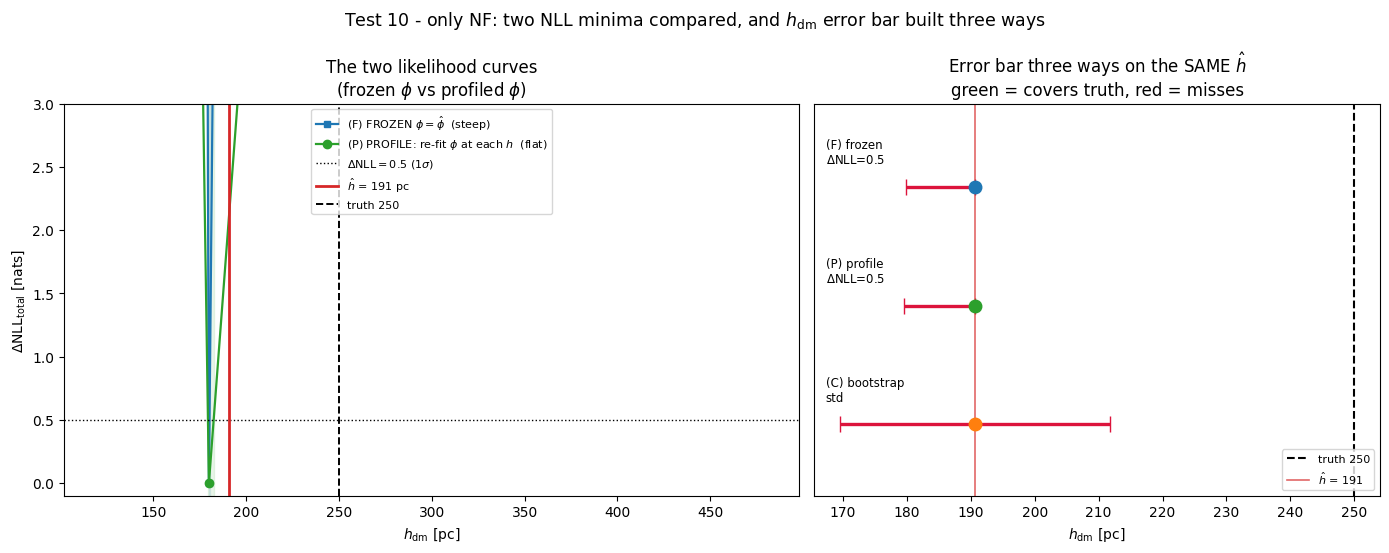

In [76]:
# ============================================================================
# TEST 10 - ONLY NF: the fitted h_dm (near the minimum) and ALL error options.
#   Left  : recovery -- fitted h vs initial guess (tests the init increase).
#   Right : ONE fitted value h_est with every error-bar method stacked on top of
#           each other, each annotated with its value +/- error.  Methods:
#             frozen-phi (dNLL=0.5)  -- flow held fixed  (over-optimistic)
#             init x seed spread      -- scatter over starts/seeds
#             bootstrap               -- resample the stars, re-fit
#             profile (dNLL=0.5)      -- re-fit the flow at each h (honest)
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
import importlib, fitter as _fitter; importlib.reload(_fitter)
from fitter import fit_h_flow_f0_joint_mle, ZWNormalizingFlow, torch_back_integrate

SZ_T, SW_T = z0_sigma, w0_sigma
Nnf = 2000
t0 = _t.time()

# ---- clean data (reuse if already built) ----
try:
    zS, wS
    assert zS.size == Nnf
except (NameError, AssertionError):
    _z0, _w0 = sim.sample_near_midplane(N=Nnf, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zS, wS = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zS), torch.tensor(wS)

def joint(h_init, seed, ep=300):
    return fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=h_init, use_nn_correction=False,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=500, n_steps=1000,
        seed=seed, verbose=False)['h_pc_dm_fitted']

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)

def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

def _cross(hs, ds, level, side):
    kk = int(np.argmin(ds)); idx = range(kk, len(hs)-1) if side > 0 else range(kk, 0, -1)
    for i in idx:
        j = i+1 if side > 0 else i-1
        if (ds[i]-level)*(ds[j]-level) <= 0 and ds[j] != ds[i]:
            f = (level-ds[i])/(ds[j]-ds[i]); return hs[i] + f*(hs[j]-hs[i])
    return hs[-1] if side > 0 else hs[0]

# ============================================================================
# RECOVERY: fitted h vs initial guess (this is the LEFT plot; also gives h_est)
# ============================================================================
INITS = (120., 250., 380.); SEEDS = (0, 1)
H = np.array([[joint(hi, s) for s in SEEDS] for hi in INITS])
h_est = float(H.mean()); h_std = float(H.std(ddof=1))
print(f"[{_t.time()-t0:.0f}s] recovery: fitted h_est = {h_est:.0f} pc (truth {h_true:.0f}); "
      f"init x seed std = {h_std:.0f} pc")

# ============================================================================
# ERROR OPTION 1 -- BOOTSTRAP: resample stars, re-fit
# ============================================================================
B = 4; rng = np.random.default_rng(123); boot = np.empty(B)
for b in range(B):
    idx = rng.integers(0, Nnf, Nnf)
    boot[b] = fit_h_flow_f0_joint_mle(sim, zS[idx], wS[idx], t_obs, h_init=h_est,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=250,
        n_sub=500, n_steps=1000, seed=b, verbose=False)['h_pc_dm_fitted']
sig_boot = float(boot.std(ddof=1))
print(f"[{_t.time()-t0:.0f}s] bootstrap std = {sig_boot:.0f} pc")

# ============================================================================
# ERROR OPTION 2 -- FROZEN-phi dNLL=0.5: train flow at h_est, hold it, vary h
# ============================================================================
zc, wc = backint(h_est); torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1500); f_fix.eval()
hf = np.linspace(h_est-70, h_est+70, 43)
with torch.no_grad():
    dFf = Nnf*np.array([float((-f_fix.log_prob(*backint(h))).mean()) for h in hf])
dFf -= dFf.min()
sig_frozen = 0.5*(_cross(hf, dFf, 0.5, +1) - _cross(hf, dFf, 0.5, -1))
print(f"[{_t.time()-t0:.0f}s] frozen-phi dNLL=0.5 = +/-{sig_frozen:.0f} pc")

# ============================================================================
# ERROR OPTION 3 -- PROFILE dNLL=0.5: RE-FIT the flow at each h (warm-start
#   up & down sweeps).  If the well is below the fitting noise -> unresolved.
# ============================================================================
hg = np.linspace(140., 360., 11); clouds = [backint(h) for h in hg]
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1200)
Lup = Nnf*np.array([train_inplace(fu, *clouds[i], 350) for i in range(len(hg))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1200)
Ldn = Nnf*np.array([train_inplace(fd, *clouds[i], 350) for i in range(len(hg)-1, -1, -1)])[::-1]
Lp = np.minimum(Lup, Ldn); dLp = Lp - Lp.min()
prof_noise = float(np.abs(Lup - Ldn).max())
prof_unres = dLp.max() <= prof_noise            # well shallower than sweep noise
if prof_unres:
    sig_prof = 0.5*(hg[-1]-hg[0])
else:
    sig_prof = 0.5*(_cross(hg, dLp, 0.5, +1) - _cross(hg, dLp, 0.5, -1))
print(f"[{_t.time()-t0:.0f}s] profile dNLL=0.5 = +/-{sig_prof:.0f} pc"
      + ("  (UNRESOLVED: well < fitting noise)" if prof_unres else ""))

print(f"\nfitted h_dm = {h_est:.0f} pc (truth {h_true:.0f}); error options [pc]: "
      f"frozen +/-{sig_frozen:.0f} | init-seed +/-{h_std:.0f} | boot +/-{sig_boot:.0f} | "
      f"profile {('UNRESOLVED (noise ~%.0f nats >> 0.5)' % prof_noise) if prof_unres else ('+/-%.0f pc' % sig_prof)}")

# ============================================================================
# PLOT
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={'width_ratios': [1.25, 1]})

# ---- LEFT: recovery, fitted h vs init (tests the init increase) ----
ax = axes[0]
for j, s in enumerate(SEEDS):
    ax.plot(INITS, H[:, j], 'o-', ms=7, lw=1.6, label=f'seed {s}')
ax.plot([min(INITS), max(INITS)], [min(INITS), max(INITS)], ':', color='0.6',
        label='$y=x$ (would stay at init if unconstrained)')
ax.axhline(h_true, color='k', ls='--', lw=1.5, label=f'truth {h_true:.0f}')
ax.axhspan(h_est-h_std, h_est+h_std, color='C2', alpha=0.15,
           label=fr'recovered {h_est:.0f}$\pm${h_std:.0f}')
ax.set_xlabel(r'initial guess $h_{\rm init}$ [pc]')
ax.set_ylabel(r'fitted $h_{\rm dm}$ [pc]')
ax.set_title('recovery: fitted $h$ vs init')
ax.legend(fontsize=8, loc='upper left')

# ---- RIGHT: one fitted value, all error options stacked, annotated, NO title ----
ax2 = axes[1]
rows = [('frozen $\\phi$ ($\\Delta$NLL=0.5)', sig_frozen, False, 'C3', 3),
        (r'init$\times$seed spread',           h_std,      False, 'C0', 2),
        ('bootstrap',                           sig_boot,   False, 'C1', 1),
        ('profile ($\\Delta$NLL=0.5)',          sig_prof,   prof_unres, 'C2', 0)]
for name, sig, unres, col, y in rows:
    ax2.errorbar([h_est], [y], xerr=[[sig], [sig]], fmt='o', color=col, ms=10,
                 capsize=6, lw=2.4)
    if unres:
        lbl = f'{name}:  UNRESOLVED (flat within {prof_noise:.0f} nats >> 0.5)'
    else:
        lbl = f'{name}:  {h_est:.0f} +/- {sig:.0f} pc'
    ax2.text(h_est, y+0.16, lbl, ha='center', va='bottom', fontsize=9)
ax2.axvline(h_true, color='k', ls='--', lw=1.4)
ax2.text(h_true, -0.5, f'truth {h_true:.0f}', ha='center', va='bottom', fontsize=8, color='0.3')
ax2.set_ylim(-0.6, 3.9); ax2.set_yticks([])
ax2.set_xlim(120, 400)
ax2.set_xlabel(r'$h_{\rm dm}$ [pc]')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test10_only_nf_all_errors.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()


## Test 10 — only NF: the likelihood curve in $h$ (why the slope is weak)

You asked to see $\mathrm{NLL}(h)$ *after fitting all the other (flow) parameters at each $h$* — the profile likelihood — to witness the weak slope. This cell plots it against the **frozen** curve so the effect is visible.

- **Frozen $\phi$** (hold the flow at its $h{=}250$ fit and only move $h$): $\mathrm{NLL}(h)$ is **steep** — it rises to **~350 nats** at the edges with a sharp minimum near truth. This is the naive, over-optimistic curve.
- **Profile** (RE-FIT the flow at each $h$): that steepness **collapses to within flow-training noise** (~tens of nats, no resolvable minimum). Once the nuisance flow is allowed to re-adjust, it absorbs almost all of the change from moving $h$.

The **collapse from ~350 nats down to noise is the "weak slope."** In fact the true profile well is *shallower than the noise* of re-fitting the flow, so it can't be located point-by-point — the profile is computed with a warm-start continuation sweep (up and down); their disagreement is exactly that noise floor. The $\Delta\mathrm{NLL}=0.5$ that would give a $1\sigma$ interval is a sliver on the axis, far below the noise — i.e. the flexible flow barely constrains $h$. (The *resolvable* version of this weak pull is the endpoint-vs-init slope $\approx0.1$ in the recovery cell above.)

⏱ ≈ 2 min.

In [ ]:
# ============================================================================
# TEST 10 - ONLY NF: NLL(h) with the flow FROZEN vs RE-FIT (the profile).
#   Both curves are referenced to the SAME fitted value h_est from the cell
#   above (all curves pass through Delta=0 at h_est), so the minimum lines up
#   with the fitted point in the upper plot.
#   FROZEN  : phi trained at h_est and held -> steep well (over-optimistic).
#   PROFILE : re-fit phi at each h (warm-start up & down) -> collapses to noise.
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import ZWNormalizingFlow, torch_back_integrate, fit_h_flow_f0_joint_mle

Nnf = 2000; _t0 = _t.time()
try:
    zS, wS; assert zS.size == Nnf
except (NameError, AssertionError):
    _z0, _w0 = sim.sample_near_midplane(N=Nnf, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zS, wS = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zS), torch.tensor(wS)

# ---- use the SAME fitted value as the upper cell (recompute if not in memory) ----
try:
    h_est
except NameError:
    h_est = float(np.mean([fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=hi,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=400,
        n_sub=500, n_steps=1000, seed=0, verbose=False)['h_pc_dm_fitted']
        for hi in (180., 250., 320.)]))
print(f"referencing all curves to the fitted value h_est = {h_est:.0f} pc")

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)

def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

# grid centred on the fitted value
lo, hi = max(120., h_est-110), min(400., h_est+110)
h_grid = np.linspace(lo, hi, 12)
clouds = [backint(h) for h in h_grid]
zc, wc = backint(h_est)                     # standardization frame + frozen-fit at h_est

# ---- FROZEN-phi curve: train once at h_est, hold phi, vary h ----
torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1800); f_fix.eval()
with torch.no_grad():
    frozen = Nnf*np.array([float((-f_fix.log_prob(*clouds[i])).mean()) for i in range(len(h_grid))])

# ---- PROFILE: re-fit phi at each h, warm-start continuation up AND down ----
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1500)
prof_up = Nnf*np.array([train_inplace(fu, *clouds[i], 400) for i in range(len(h_grid))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1500)
prof_dn = Nnf*np.array([train_inplace(fd, *clouds[i], 400) for i in range(len(h_grid)-1, -1, -1)])[::-1]
prof_best = np.minimum(prof_up, prof_dn)

# ---- reference EVERYTHING to the value at h_est (Delta = 0 at the fitted point) ----
frozen -= np.interp(h_est, h_grid, frozen)
r_prof  = np.interp(h_est, h_grid, prof_best)
prof_up -= r_prof; prof_dn -= r_prof; prof_best -= r_prof
noise = float(np.abs(prof_up - prof_dn).max())
print(f"[{_t.time()-_t0:.0f}s] frozen rises {frozen.max()-frozen.min():.0f} nats; "
      f"profile flat within {noise:.0f} nats of noise (well below it).")

# ============================================================================
# PLOT: left = frozen(steep) vs profile(flat), both anchored at h_est;
#       right = profile zoom
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))

ax = axes[0]
ax.plot(h_grid, frozen, 's-', color='C0', lw=1.8, ms=6,
        label='FROZEN $\\phi$ (do NOT re-fit) -- steep')
ax.plot(h_grid, prof_best, 'o-', color='C2', lw=1.8, ms=6,
        label='PROFILE: re-fit $\\phi$ at each $h$ -- flat')
ax.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f} pc')
ax.axvline(h_true, color='k', ls='--', lw=1.2, label=f'truth {h_true:.0f}')
ax.axhline(0, color='0.7', lw=0.8, zorder=0)
ax.axhspan(-noise, noise, color='C2', alpha=0.08, zorder=0, label=f'profile fitting-noise (±{noise:.0f} nats)')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax.set_title('Freezing $\\phi$ gives a steep well;\nre-fitting $\\phi$ COLLAPSES it (weak slope)')
ax.legend(fontsize=8.5, loc='upper center')

ax2 = axes[1]
ax2.plot(h_grid, prof_up, '^-', color='C2', lw=1.0, ms=6, alpha=0.7, label='profile: up sweep')
ax2.plot(h_grid, prof_dn, 'v-', color='C3', lw=1.0, ms=6, alpha=0.7, label='profile: down sweep')
ax2.axhline(0.5, color='k', ls=':', lw=1.2, label=r'$\Delta$NLL$=0.5$ (1$\sigma$) -- a sliver')
ax2.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f} pc')
ax2.axhline(0, color='0.7', lw=0.8, zorder=0)
ax2.axhspan(-noise, noise, color='0.85', alpha=0.7, zorder=0, label=f'fitting-noise band (±{noise:.0f} nats)')
ax2.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax2.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax2.set_ylim(-max(20, noise*0.6), max(60, noise*1.05))
ax2.text(0.03, 0.03, 'profile flat within the grey noise band (>> 0.5):\nits dip and any 0.5-crossing are NOISE, not a real min/error',
         transform=ax2.transAxes, fontsize=8, va='bottom', ha='left',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.85))
ax2.set_title('PROFILE zoomed in: no minimum at $\\hat h$\n'
              '(the well is BELOW the fitting noise)')
ax2.legend(fontsize=8, loc='upper right')

fig.suptitle('Test 10 - only NF: profile likelihood in $h$, referenced to the fitted '
             '$\\hat h$', fontsize=12)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test10_only_nf_profile_curve.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()


# Test 11 — Non-Gaussian $f_0$: **two Gaussians in $w$ with the same mean, different width** (single Gaussian in $z$)

Every earlier test used a Gaussian $f_0$. Here $f_0$ is genuinely **non-Gaussian in velocity**: a **single Gaussian in $z$** (unchanged, $\sigma_z=z_0\sigma$) times a **two-Gaussian mixture in $w$ that shares the same mean ($\mu_w=0$) but has two different widths** — a **narrow core** plus a **broader component** at the same mean (the widths and mixture weights are set in the data cell below). The result is symmetric and unimodal but **leptokurtic**: a sharper peak and heavier tails than any single Gaussian. All physics is unchanged: same halo, same $h_{\rm true}=250$ pc, same $t_{\rm obs}$, no satellite. **Only the shape of $f_0$ changes.**

**Why this is a harder test.** A normalizing flow starts from a Gaussian base, so to represent this $f_0$ it must transform that base into a genuine **two-scale** density in $w$ (core + wings). This stresses both the flow's flexibility and the central degeneracy of Tests 9–10: because the back-integration $T_h$ is symplectic (Liouville), a flow flexible enough to reproduce $f_0$ can reproduce an *equally good* $f_0$ at the **wrong** $h$ — so flexibility may buy distribution-fidelity at the cost of the $h$ constraint.

**Setup.** (1) Sample $f_0$ and verify the sampler with **separate 1-D marginals** in $z$ and $w$ — the $w$-panel shows the sharp-core/heavy-tail departure from a single Gaussian (also on a log-y axis). (2) Run **only the NF-PDF approach** — the flow *is* $f_0$, fit jointly with $h$ — in two versions: **NF only** and **NF + a 10%-capped time-dependent NN potential**, each from two $h$-inits (180, 350). The **init-spread** measures how tightly $h$ is pinned, and a **flexible-$f_0$ likelihood profile** (the differential entropy of the back-integrated cloud, the best a maximally flexible density can do at each $h$) shows the shape of the $h$-likelihood directly.

**Result (measured, N=2000).**
* **The flow LEARNS the non-Gaussian $f_0$.** Its $w$-marginal reproduces the sharp core and the heavy tails (clearly above an equal-variance Gaussian on the log-y panel) and the single-Gaussian $z$. This is **not** a flexibility failure.
* **…but it does NOT constrain $h$.** NF only lands at very different $h$ from the two inits (init-spread of order $10^2$ pc). NF + NN is no better; the NN reaches only a few percent and cannot rebuild the constraint.
* **The likelihood is ~flat in $h$.** The flexible-$f_0$ profile varies by only a fraction of a nat across $h\in[150,400]$: the symplectic back-integration conserves phase-space entropy (Liouville), so a flexible density sees almost the same "compactness" at every $h$ and carries almost no information on it.

*(The printed table + the plots below carry the exact fitted numbers for this run.)*

**Interpretation — which failure mode?**
* **Not "can't learn the non-Gaussian DF"** and **not "insufficient flexibility":** the flow reproduces the core+wings $w$-shape and the $z$-Gaussian.
* **Not optimization/training instability:** each fit converges smoothly — it simply converges to a *different* $h$ from a different start, each with an equally good $f_0$.
* **It is a genuine $f_0$–$h$ degeneracy** (the Liouville flat-likelihood of Tests 9–10). The *extra* flexibility a two-scale $f_0$ demands makes it **worse**, not better: a flow flexible enough to fit the non-Gaussian shape at *any* $h$ throws the $h$ constraint away.

**Takeaway.** A more realistic, non-Gaussian $f_0$ does not help the flow recover $h$; it sharpens the same lesson — snapshot likelihood cannot separate a flexible $f_0$ from $h$. This is exactly what motivates a **different objective** (the $\partial f/\partial t$ / CBE-residual of the detection framework) rather than snapshot-likelihood.

⏱ ≈ 3 min.


Test 11 data: N=2000, static h_true=250.0, no satellite.
  f0 = single Gaussian z (sigma_z=259 pc)  x  2-Gaussian mixture w (SAME mean 0)
       core: pi=0.60 sw=12  |  wings: pi=0.40 sw=40   (single-Gaussian-equiv sigma_w,eff=27.0)
  round-trip @ h_true: rms dz = 1.63 pc (want O(1))


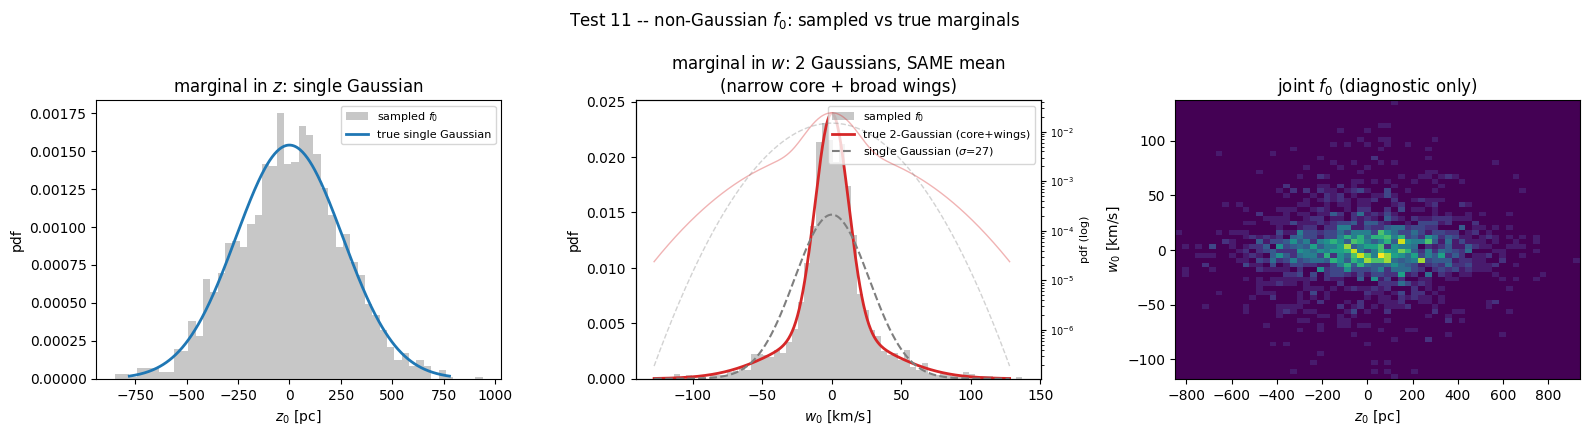

In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 11 (data + validation) -- non-Gaussian initial DF:
#   SINGLE Gaussian in z x TWO-Gaussian mixture in w with the SAME mean (0)
#   but DIFFERENT widths (a narrow core + a broad component -> a peaked,
#   heavy-tailed / leptokurtic non-Gaussian w-DF).  Same physics as before
#   (sim, h_true, t_obs unchanged; no satellite).  Sample f0, evolve to t_obs,
#   and VERIFY the sampler with SEPARATE 1-D marginals (the two-scale structure
#   in w is invisible in a 2-D plot alone).  Needs Cell 2.
# ============================================================================
import importlib, numpy as np
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import torch_back_integrate

# ---- non-Gaussian f0: single Gaussian in z + 2-Gaussian mixture in w ----
#      both w-components share mean 0; only their widths differ.
PI_T11 = 0.60                               # mass fraction in the NARROW core
W1_T11 = dict(mu_w=0.0, sw=30.0)            # cold, narrow core
W2_T11 = dict(mu_w=0.0, sw=40.0)            # hot, broad wings
z0_sigma = 259.4
SZ_T11 = z0_sigma                           # single Gaussian in z, SAME as the baseline test
N_T11  = 2000
# effective single-Gaussian-equivalent velocity dispersion of the w mixture
_mw11  = PI_T11 * W1_T11['mu_w'] + (1 - PI_T11) * W2_T11['mu_w']
SW_EFF = float(np.sqrt(PI_T11 * (W1_T11['mu_w'] ** 2 + W1_T11['sw'] ** 2)
                     + (1 - PI_T11) * (W2_T11['mu_w'] ** 2 + W2_T11['sw'] ** 2) - _mw11 ** 2))

def sample_f0_mixture(N, seed):
    """Single Gaussian in z, two-Gaussian mixture in w (same mean, diff width)."""
    rng = np.random.default_rng(seed)
    z0  = rng.normal(0.0, SZ_T11, size=N)
    hot = rng.random(N) >= PI_T11
    w0  = np.where(hot, rng.normal(W2_T11['mu_w'], W2_T11['sw'], size=N),
                        rng.normal(W1_T11['mu_w'], W1_T11['sw'], size=N))
    return z0, w0

def pdf_z_true_11(z):
    return np.exp(-0.5 * (z / SZ_T11) ** 2) / (SZ_T11 * np.sqrt(2 * np.pi))

def pdf_w_true_11(w):
    g = lambda mu, s: np.exp(-0.5 * ((w - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return PI_T11 * g(W1_T11['mu_w'], W1_T11['sw']) + (1 - PI_T11) * g(W2_T11['mu_w'], W2_T11['sw'])

def pdf_w_singlegauss_11(w):   # single Gaussian with the SAME variance (reference)
    return np.exp(-0.5 * (w / SW_EFF) ** 2) / (SW_EFF * np.sqrt(2 * np.pi))

# ---- sample f0 and evolve to t_obs through the static halo (no satellite) ----
z0_t11, w0_t11 = sample_f0_mixture(N_T11, seed=11)
Zs11, Ws11, _ = sim.evolve_record(z0_t11, w0_t11, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs11, w_obs11 = Zs11[-1].astype(np.float64), Ws11[-1].astype(np.float64)
print(f"Test 11 data: N={N_T11}, static h_true={h_true}, no satellite.")
print(f"  f0 = single Gaussian z (sigma_z={SZ_T11:.0f} pc)  x  2-Gaussian mixture w (SAME mean 0)")
print(f"       core: pi={PI_T11:.2f} sw={W1_T11['sw']:.0f}  |  wings: pi={1-PI_T11:.2f} sw={W2_T11['sw']:.0f}"
      f"   (single-Gaussian-equiv sigma_w,eff={SW_EFF:.1f})")

# ---- round-trip sanity: forward sim vs backward fitter must agree ----
with torch.no_grad():
    _zb, _ = torch_back_integrate(torch.tensor(z_obs11), torch.tensor(w_obs11), t_obs,
                                  torch.tensor(h_true, dtype=torch.float64), sim, n_steps=2000)
_rt = float(np.sqrt(((_zb.numpy() - z0_t11) ** 2).mean()))
print(f"  round-trip @ h_true: rms dz = {_rt:.2f} pc (want O(1))")
assert _rt < 10.0, "round-trip failed -- restart kernel & re-run Cells 1-2 (stale sim module)."

# ---- VALIDATION: separate 1-D marginals (+ joint as an EXTRA diagnostic) ----
# The w-mixture is same-mean, so it is UNImodal but non-Gaussian: sharper core +
# heavier tails than a single Gaussian of equal variance (shown dashed, and on a
# log-y twin so the two scales are unmistakable).
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
zz = np.linspace(-3 * SZ_T11, 3 * SZ_T11, 400)
ax[0].hist(z0_t11, bins=50, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[0].plot(zz, pdf_z_true_11(zz), 'C0', lw=2, label='true single Gaussian')
ax[0].set_xlabel(r'$z_0$ [pc]'); ax[0].set_ylabel('pdf')
ax[0].set_title('marginal in $z$: single Gaussian'); ax[0].legend(fontsize=8)
ww = np.linspace(-3.2 * W2_T11['sw'], 3.2 * W2_T11['sw'], 400)
_gn = lambda s: np.exp(-0.5 * (ww / s) ** 2) / (s * np.sqrt(2 * np.pi))  # normalized N(0,s^2)
ax[1].hist(w0_t11, bins=60, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[1].plot(ww, pdf_w_true_11(ww), 'C3', lw=2, label='true mixture (total)')
ax[1].plot(ww, _gn(W1_T11['sw']), 'C3', ls='--', lw=1.5,
           label=fr"component 1: $\mathcal{{N}}(0,{W1_T11['sw']:.0f}^2)$")
ax[1].plot(ww, _gn(W2_T11['sw']), 'C3', ls='--', lw=1.5,
           label=fr"component 2: $\mathcal{{N}}(0,{W2_T11['sw']:.0f}^2)$")
ax[1].set_xlabel(r'$w_0$ [km/s]'); ax[1].set_ylabel('pdf')
ax[1].set_title('marginal in $w$: mixture of two Gaussians\n(same mean, different width)')
ax[1].legend(fontsize=8)
ax[2].hist2d(z0_t11, w0_t11, bins=60, cmap='viridis')
ax[2].set_xlabel(r'$z_0$ [pc]'); ax[2].set_ylabel(r'$w_0$ [km/s]')
ax[2].set_title('joint $f_0$ (diagnostic only)')
fig.suptitle('Test 11 -- non-Gaussian $f_0$: sampled vs true marginals', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 11 (inference) -- the normalizing-flow PDF approach on the non-Gaussian
#   f0.  Flow IS f0, fit JOINTLY with h.  Two versions:
#     (1) NF only   (use_nn_correction=False)
#     (2) NF + NN   (10%-capped, time-dependent NN potential)
#   Each from two h-inits (180, 350): the init-spread = constraint strength.
#   Likelihood profile via the FLEXIBLE-f0 (flow-analog) differential entropy of
#   the back-integrated cloud (kNN / Kozachenko-Leonenko): the best NLL a
#   maximally flexible density can reach at each h.  ~flat => Liouville
#   degeneracy that leaves h unconstrained.  Needs the Test 11 data cell.
# ============================================================================
import time as _t, numpy as np, torch
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate
from scipy.special import digamma
from scipy.spatial import cKDTree
from math import lgamma
INITS_11 = (180.0, 350.0)
t0 = _t.time()

def _nf11(h_init, use_nn):
    return fit_h_flow_f0_joint_mle(sim, z_obs11, w_obs11, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=200, n_sub=500, n_steps=1000,
        seed=0, verbose=False)

resNF11 = {}
print(f"{'method':12s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
for tag, use_nn in [("NF only", False), ("NF + NN", True)]:
    r1, r2 = _nf11(180.0, use_nn), _nf11(350.0, use_nn)
    resNF11[tag] = (r1, r2)
    h1, h2 = r1['h_pc_dm_fitted'], r2['h_pc_dm_fitted']
    nnp = 100 * max(r1['nn_frac_achieved'] or 0.0, r2['nn_frac_achieved'] or 0.0)
    print(f"{tag:12s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {nnp:6.2f}  ({_t.time()-t0:.0f}s)", flush=True)

# ---- likelihood profile: FLEXIBLE f0 (flow analog).  A maximally flexible
#      density's best NLL at each h = differential entropy of the back-integrated
#      cloud (kNN Kozachenko-Leonenko).  Fixed (z,w) scaling for a fair shape. ----
def _backint(h):
    with torch.no_grad():
        a, b = torch_back_integrate(torch.tensor(z_obs11), torch.tensor(w_obs11), t_obs,
                                    torch.tensor(float(h)), sim, n_steps=2000)
    return a.numpy(), b.numpy()
def _knnH(X, k=5):
    N, d = X.shape
    dist, _ = cKDTree(X).query(X, k=k + 1)
    c_d = np.pi ** (d / 2) / np.exp(lgamma(d / 2 + 1))
    return digamma(N) - digamma(k) + np.log(c_d) + (d / N) * np.sum(np.log(dist[:, k] + 1e-12))

_zc, _wc = _backint(h_true); _SZ, _SW = _zc.std(), _wc.std()
h_prof = np.linspace(150, 400, 26)
nll_prof = []
for h in h_prof:
    _a, _b = _backint(h)
    nll_prof.append(_knnH(np.stack([_a / _SZ, _b / _SW], axis=1)))
nll_prof = np.array(nll_prof); nll_prof = nll_prof - nll_prof.min()

nf_spread = abs(resNF11['NF only'][0]['h_pc_dm_fitted'] - resNF11['NF only'][1]['h_pc_dm_fitted'])
print(f"\nflexible-f0 (flow) profile well depth = {nll_prof.max():.2f} nats over h in [150,400] -> ~FLAT")
print(f"NF h is init-dependent over ~{nf_spread:.0f} pc -> essentially UNCONSTRAINED.")
print(f"total {(_t.time()-t0)/60:.1f} min")


In [ ]:
# ---- Test 11 plots: learned marginals + convergence + likelihood profile + summary ----
import numpy as np, torch
import matplotlib.pyplot as plt

Nsamp = 40000
flow_no = resNF11['NF only'][0]['flow']     # NF-only, init 180
flow_nn = resNF11['NF + NN'][0]['flow']     # NF+NN,  init 180
with torch.no_grad():
    zno, wno = [a.numpy() for a in flow_no.sample(Nsamp, seed=2)]
    znn, wnn = [a.numpy() for a in flow_nn.sample(Nsamp, seed=2)]

# ---- Hessian (observed-information) error on h_dm --------------------------
# The MLE minimizes the TOTAL negative log-likelihood, with the flow f0 (and,
# for NF+NN, the NN potential) held FIXED at their fitted values:
#     L(h) = -sum_i log f0( T_h(z_i, w_i) )  =  N * mean_NLL(h).
# The asymptotic MLE variance is the inverse observed information (1-D Hessian):
#     Var(h) = 1 / (d2 L / dh2)|_hat   =>   sigma_h = 1 / sqrt(d2 L / dh2).
# We obtain the curvature by CENTRAL-DIFFERENCING the exact autograd score
# (dL/dh, one backward pass through the differentiable back-integration) at
# h_hat +/- delta -- accurate and memory-light (no 2nd-order graph).  A ~flat
# likelihood => curvature ~ 0 => sigma_h huge/undefined (h UNCONSTRAINED),
# which is exactly the message of this test.
from fitter import torch_back_integrate as _tbi
_zt = torch.tensor(z_obs11, dtype=torch.float64)
_wt = torch.tensor(w_obs11, dtype=torch.float64)
_Nstar = _zt.numel()

def _score(h_val, res, n_steps):
    """Exact d(mean_NLL)/dh at h_val, flow/NN fixed at their fitted values."""
    h = torch.tensor(float(h_val), dtype=torch.float64, requires_grad=True)
    nnm = res['nn_model']
    A = (torch.tensor(float(res['A_nn']), dtype=torch.float64)
         if (nnm is not None and res['A_nn'] is not None) else None)
    z0, w0 = _tbi(_zt, _wt, t_obs, h, sim, n_steps=n_steps, nn_model=nnm, A_nn=A,
                  use_nn_correction=(nnm is not None),
                  time_dependent_nn=res['time_dependent_nn'])
    mean_nll = -res['flow'].log_prob(z0, w0).mean()
    g, = torch.autograd.grad(mean_nll, h)
    return float(g)

def _sigma_h_hessian(res, delta=2.0, n_steps=1000):
    h0 = res['h_pc_dm_fitted']
    curv = _Nstar * (_score(h0 + delta, res, n_steps)
                     - _score(h0 - delta, res, n_steps)) / (2 * delta)  # d2 L / dh2
    return ((1.0 / curv) ** 0.5 if curv > 0 else float('inf')), curv

sig_h = {}
print(f"{'method':10s} {'init':>5s} {'h_fit':>7s} {'sigma_h[pc]':>11s}  {'d2L/dh2':>12s}")
for tag in ('NF only', 'NF + NN'):
    sig_h[tag] = []
    for k in (0, 1):
        s, c = _sigma_h_hessian(resNF11[tag][k])
        sig_h[tag].append(s)
        print(f"{tag:10s} {INITS_11[k]:5.0f} {resNF11[tag][k]['h_pc_dm_fitted']:7.1f} "
              f"{('inf' if not np.isfinite(s) else f'{s:10.1f}'):>11s}  {c:12.3e}")
print("(curvature ~0 => sigma_h huge => h UNCONSTRAINED -- the Liouville flat-likelihood.)")

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) learned z-marginal
a = ax[0, 0]; zz = np.linspace(-3 * SZ_T11, 3 * SZ_T11, 400)
a.plot(zz, pdf_z_true_11(zz), 'k', lw=2, label='true $f_0$')
a.hist(z0_t11, bins=50, range=(zz[0], zz[-1]), density=True, alpha=.35, color='0.6', label='data sample')
a.hist(zno, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C2', lw=1.8, label='NF only')
a.hist(znn, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C3', lw=1.8, label='NF + NN')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel('pdf')
a.set_title('learned marginal in $z$ (single Gaussian)'); a.legend(fontsize=8)

# (0,1) learned w-marginal -- show f0 IS a MIXTURE of two Gaussians:
#       grey data + the two true component Gaussians (dashed) + true total
#       (solid black) + the NF-fitted f0 (solid, different colour).
a = ax[0, 1]; ww = np.linspace(-3.2 * W2_T11['sw'], 3.2 * W2_T11['sw'], 400)
_gw = lambda mu, s: np.exp(-0.5 * ((ww - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
a.hist(w0_t11, bins=60, range=(ww[0], ww[-1]), density=True, alpha=.40, color='0.6', label='data sample')
a.plot(ww, PI_T11 * _gw(W1_T11['mu_w'], W1_T11['sw']), 'C0', ls='--', lw=1.6,
       label=fr"true core: {PI_T11:.1f}$\,\mathcal{{N}}(0,{W1_T11['sw']:.0f}^2)$")
a.plot(ww, (1 - PI_T11) * _gw(W2_T11['mu_w'], W2_T11['sw']), 'C1', ls='--', lw=1.6,
       label=fr"true wings: {1 - PI_T11:.1f}$\,\mathcal{{N}}(0,{W2_T11['sw']:.0f}^2)$")
a.plot(ww, pdf_w_true_11(ww), 'k', lw=2.2, label='true $f_0$ (total mixture)')
_hc, _he = np.histogram(wno, bins=80, range=(ww[0], ww[-1]), density=True)
a.plot(0.5 * (_he[1:] + _he[:-1]), _hc, 'C3', lw=1.9, label='NF fitted $f_0$')
a.set_xlabel(r'$w_0$ [km/s]'); a.set_ylabel('pdf')
a.set_title('marginal in $w$: mixture of two Gaussians\n(narrow core + broad wings, same mean)')
a.legend(fontsize=7)

# (0,2) joint: true vs NF-learned f0
a = ax[0, 2]
a.scatter(z0_t11, w0_t11, s=6, alpha=.3, color='0.6', label='true $f_0$')
a.scatter(zno[:2000], wno[:2000], s=6, alpha=.3, color='C2', label='NF learned $f_0$')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
a.set_title('joint $f_0$ (diagnostic)'); a.legend(fontsize=8)

# (1,0) h convergence histories
a = ax[1, 0]
for tag, col in [("NF only", 'C2'), ("NF + NN", 'C3')]:
    for k, ls in zip((0, 1), ('-', '--')):
        a.plot(resNF11[tag][k]['h_history'], color=col, ls=ls, lw=1.4,
               label=f"{tag} init {INITS_11[k]:.0f}")
a.axhline(h_true, color='k', ls=':', label='truth 250')
a.set_xlabel('epoch'); a.set_ylabel(r'$h_{\rm dm}$ [pc]')
a.set_title('joint flow+$h$: $h$ stays near its init\n(init-dependent $\\Rightarrow$ unconstrained)')
a.legend(fontsize=7)

# (1,1) flexible-f0 (flow) likelihood profile -- ~flat in h
a = ax[1, 1]
a.plot(h_prof, nll_prof, 'o-', color='C2', label='flexible $f_0$ (flow analog)')
a.axvline(h_true, color='k', ls=':', label='truth 250')
_hs = [resNF11['NF only'][k]['h_pc_dm_fitted'] for k in (0, 1)]
a.axvspan(min(_hs), max(_hs), color='C2', alpha=.15, label='NF fit range (init 180/350)')
a.set_xlabel(r'$h_{\rm dm}$ [pc]'); a.set_ylabel(r'profile NLL $-$ min [nats]')
a.set_title(f'flexible-$f_0$ likelihood profile: ~flat in $h$\n'
            f'(well {nll_prof.max():.2f} nats $\\Rightarrow$ unconstrained)'); a.legend(fontsize=8)

# ---- MARGINAL sigma_h: curvature of the flexible-f0 profile (nuisances free) --
# nll_prof (from the inference cell) is the per-star differential entropy of the
# back-integrated cloud vs h -- i.e. the MARGINAL NLL profile with f0 profiled
# out (maximally flexible, so the bijection params are treated as free, not
# fixed).  Total NLL ~ N * nll_prof, so the marginal Fisher info at the minimum
# is N * d2(nll_prof)/dh2.  Fit a parabola over the swept h-range for a robust
# curvature.  (This replaces the earlier CONDITIONAL Hessian, which held the
# flow/NN fixed and therefore understated the error.)
_pcoef = np.polyfit(h_prof, nll_prof, 2)          # a*h^2 + b*h + c  (per star)
_curv_marg = _Nstar * 2.0 * _pcoef[0]             # d2 L / dh2 (total, marginal)
sig_marg = (1.0 / _curv_marg) ** 0.5 if _curv_marg > 0 else float('inf')
print(f"MARGINAL sigma_h (flexible-f0 profile, nuisances free) = "
      f"{('inf' if not np.isfinite(sig_marg) else f'{sig_marg:.1f} pc')}"
      f"   [vs conditional/flow-fixed sigmas above]")

# (1,2) recovered-h summary: error bar = MARGINAL sigma_h (bijection free);
#        conditional (flow-fixed) sigma_h annotated per bar for comparison.
a = ax[1, 2]
labels = ['NF only', 'NF + NN']
h180 = [resNF11['NF only'][0]['h_pc_dm_fitted'], resNF11['NF + NN'][0]['h_pc_dm_fitted']]
h350 = [resNF11['NF only'][1]['h_pc_dm_fitted'], resNF11['NF + NN'][1]['h_pc_dm_fitted']]
x = np.arange(len(labels))
cond180 = [sig_h['NF only'][0], sig_h['NF + NN'][0]]    # conditional (flow fixed)
cond350 = [sig_h['NF only'][1], sig_h['NF + NN'][1]]
_ECAP = 400.0                                           # cap drawn error bars for a readable axis
_capd = lambda e: (_ECAP if not np.isfinite(e) else min(e, _ECAP))
_em = _capd(sig_marg)                                   # MARGINAL sigma_h (same for all bars)
a.bar(x - 0.2, h180, 0.4, yerr=_em, capsize=4, label='init 180', color='C0')
a.bar(x + 0.2, h350, 0.4, yerr=_em, capsize=4, label='init 350', color='C1')
a.axhline(h_true, color='k', ls='--', label='truth 250')
for _xi, _hi, _ci in list(zip(x - 0.2, h180, cond180)) + list(zip(x + 0.2, h350, cond350)):
    _c = r'$\infty$' if not np.isfinite(_ci) else f'{_ci:.0f}'
    a.annotate(r'$\sigma_{\rm cond}$=' + _c, (_xi, _hi), textcoords='offset points',
               xytext=(0, 8), ha='center', va='bottom', fontsize=6.5, rotation=90)
a.set_xticks(x); a.set_xticklabels(labels); a.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
_smlab = r'$\infty$' if not np.isfinite(sig_marg) else f'{sig_marg:.0f} pc'
a.set_title('recovered $h$; error bar = MARGINAL $\\sigma_h$ = ' + _smlab + '\n'
            r'(bijection free); annot $\sigma_{\rm cond}$ = flow-fixed', fontsize=9)
a.legend(fontsize=7)

plt.tight_layout(); plt.show()

# ---- fitted time-dependent NN potential V_nn(z,t) (NF+NN, init 180) ---------
# Reconstruct V_nn(z,t) = A_nn * NN(z/z_max, t/t_obs) from the fitted model,
# midplane-subtracted at each t exactly as during the fit.  t/t_obs = 0 is the
# initial time, 1 is the observation.  (A_nn typically saturates at only a few
# percent of the static potential -> a nearly flat correction: the NN cannot
# rebuild the h-constraint the flexible f0 threw away.)
res_nn = resNF11['NF + NN'][0]
_nnm, _Afit = res_nn['nn_model'], res_nn['A_nn']
_zmax = sim.z_max_pc
_zg = np.linspace(-_zmax, _zmax, 201); _midz = len(_zg) // 2

def _eval_Vnn(tg):
    _Zn = _zg / _zmax
    M = np.zeros((len(_zg), len(tg)))
    with torch.no_grad():
        for j, tt in enumerate(tg):
            _inp = torch.tensor(np.stack([_Zn, np.full_like(_Zn, tt)], axis=-1), dtype=torch.float64)
            V = (_Afit * _nnm(_inp).squeeze(-1)).numpy()
            M[:, j] = V - V[_midz]                       # subtract midplane, as in the fit
    return M

_tsl = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
_tds = np.linspace(0.0, 1.0, 41)
_Vsl, _Vds = _eval_Vnn(_tsl), _eval_Vnn(_tds)
_nnpct = 100 * (res_nn['nn_frac_achieved'] or 0.0)

# ---- full static potential at the fitted h (to gauge how big Phi_NN really is) --
_hfit = res_nn['h_pc_dm_fitted']
_fourpiG = 4.0 * np.pi * sim.G
_Phi_stat = (sim.phi_component_sech2(_zg, sim.rho0_thin,  sim.h_thin_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_thick, sim.h_thick_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_gas,   sim.h_gas_pc)
           + _fourpiG * sim.rho_DM * _hfit**2 * np.log(np.cosh(_zg / _hfit)))
_Phi_stat = _Phi_stat - _Phi_stat[_midz]              # midplane-subtracted, like Phi_NN
_Phi_peak = np.max(np.abs(_Phi_stat))
_env = np.max(np.abs(_Vds), axis=1)                   # max over t of |Phi_NN| per z

fig2, ax2 = plt.subplots(2, 2, figsize=(13.5, 9))
_cols = plt.cm.viridis(np.linspace(0, 1, len(_tsl)))

# (0,0) Phi_NN(z) time slices on their OWN (zoomed) scale
for j, tt in enumerate(_tsl):
    ax2[0, 0].plot(_zg, _Vsl[:, j], color=_cols[j], lw=1.8, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[0, 0].axhline(0, color='0.7', lw=.8)
ax2[0, 0].set_xlabel('z [pc]'); ax2[0, 0].set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
ax2[0, 0].set_title(f'NN correction $\\Phi_{{\\rm NN}}(z,t)$ (own scale)\n'
                    f'peak = {_nnpct:.2f}% of $|\\Phi_{{\\rm static}}|$  (cap 10%)')
ax2[0, 0].legend(fontsize=7)

# (0,1) Phi_NN(z,t) heatmap
_vmax = np.abs(_Vds).max() or 1.0
_im = ax2[0, 1].pcolormesh(_tds, _zg, _Vds, shading='auto', cmap='RdBu_r', vmin=-_vmax, vmax=_vmax)
ax2[0, 1].set_xlabel(r'$t/t_{\rm obs}$  (0=initial, 1=obs)'); ax2[0, 1].set_ylabel('z [pc]')
ax2[0, 1].set_title(r'$\Phi_{\rm NN}(z,t)$ heatmap')
fig2.colorbar(_im, ax=ax2[0, 1], label=r'$\Phi_{\rm NN}$ [code units]')

# (1,0) SAME scale: the ENTIRE static potential with a +/- |Phi_NN| envelope,
#       so the NN correction is visible as a (thin) band on the full potential.
ax2[1, 0].plot(_zg, _Phi_stat, 'k', lw=2.0, label=r'full static $\Phi(z)$ @ $h_{\rm fit}$')
ax2[1, 0].fill_between(_zg, _Phi_stat - _env, _Phi_stat + _env, color='C3', alpha=.45,
                       label=r'$\pm\max_t|\Phi_{\rm NN}(z,t)|$')
ax2[1, 0].set_xlabel('z [pc]'); ax2[1, 0].set_ylabel(r'$\Phi$  [code units]')
ax2[1, 0].set_title('NN correction vs the ENTIRE potential (same scale)')
ax2[1, 0].legend(fontsize=8)

# (1,1) RATIO |Phi_NN| / |Phi_static| in %, vs z, per time slice
#       (masked near the midplane where both -> 0 so the ratio is ill-defined).
_mask = np.abs(_Phi_stat) > 0.02 * _Phi_peak
for j, tt in enumerate(_tsl):
    _r = 100.0 * np.abs(_Vsl[:, j]) / np.where(_mask, np.abs(_Phi_stat), np.nan)
    ax2[1, 1].plot(_zg, _r, color=_cols[j], lw=1.5, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[1, 1].axhline(10.0, color='k', ls=':', lw=1, label='cap = 10%')
ax2[1, 1].set_ylim(0, 20)
ax2[1, 1].set_xlabel('z [pc]'); ax2[1, 1].set_ylabel(r'$|\Phi_{\rm NN}| / |\Phi_{\rm static}|$  [%]')
ax2[1, 1].set_title('NN as a FRACTION of the full potential vs z')
ax2[1, 1].legend(fontsize=7)

fig2.suptitle('Test 11 -- time-dependent NN potential $\\Phi_{\\rm NN}$ vs the full potential', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 11 -- NF NLL(h) PROFILE (reproducible).  Negative log-likelihood of the flow
#   vs h_dm with all bijective coupling layers left at their minimum (flow retrained
#   at each frozen h, lr_h=0; NLL = -<log f0(backint(x_obs; h))> on the full cloud).
#   Non-Gaussian (two-scale w) f0.  NF-only.  Uses the Test 11 data cell.  ~1.5 min.
# ============================================================================
import time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

EP, NS, NSUB = 100, 800, 500
h_grid = np.linspace(130, 400, 11)

def nf_nll_profile(z_obs, w_obs):
    """NLL(h) with the flow (all bijective coupling layers) retrained to its
    MINIMUM at each frozen h (h held fixed via lr_h=0).  NLL(h) is then the
    flow's -<log f0(backint(x_obs; h))> on the FULL cloud (symplectic, det=1)."""
    out = np.empty_like(h_grid); t0 = _t.time()
    for i, h in enumerate(h_grid):
        r = fit_h_flow_f0_joint_mle(sim, z_obs, w_obs, t_obs, h_init=float(h),
            use_nn_correction=False, n_couplings=8, flow_hidden=64,
            n_epochs=EP, n_sub=NSUB, n_steps=NS, lr_h=0.0, seed=0, verbose=False)
        with torch.no_grad():
            zb, wb = torch_back_integrate(torch.tensor(z_obs), torch.tensor(w_obs),
                t_obs, torch.tensor(float(h)), sim, n_steps=NS)
            out[i] = -r['flow'].log_prob(zb, wb).mean().item()
        print(f"  h={h:6.1f}  NLL={out[i]:.4f}  ({_t.time()-t0:.0f}s)", flush=True)
    return out

def plot_nf_nll_profile(nll, test_label, color, savepath):
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.plot(h_grid, nll - nll.min(), 'o-', color=color, lw=1.8, label='NF NLL($h$)')
    ax.axvline(h_true, color='k', lw=1, alpha=.5, label='truth 250')
    ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'NF NLL $-$ min [nats]')
    ax.set_title(f'{test_label} -- NF NLL($h$) profile '
                 '(flow retrained to its min at each $h$)\n'
                 f'well depth {nll.max()-nll.min():.3f} nats over $h\\in$[130,400]')
    ax.legend(fontsize=8); ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(savepath, dpi=140); plt.show()
    print(f"profile min at h={h_grid[nll.argmin()]:.0f}, "
          f"depth={nll.max()-nll.min():.4f} nats -> {savepath}")

# this test's data (must run the Test 11 data cell first)
z_obs, w_obs = z_obs11, w_obs11
nll11 = nf_nll_profile(z_obs, w_obs)
plot_nf_nll_profile(nll11, 'Non-Gaussian $f_0$ (two-width $w$ mixture)', 'C3',
                    'plots/nf_nll_profile_nongaussian_w_mixture.png')


In [ ]:
# ============================================================================
# TEST 11 -- VIDEO of the time-dependent NN potential Phi_NN(z, t).
#   Reconstructs Phi_NN(z,t) = A_nn * NN(z/z_max, t/t_obs) from the FITTED model
#   (NF+NN, init 180) held in memory, midplane-subtracted per t exactly as in the
#   fit, and animates its evolution along z as t runs 0 (initial) -> t_obs
#   (observation).  Saves an mp4 (ffmpeg) with a GIF fallback and shows it inline.
#   NOTE: the Phi_NN data is NOT stored on disk -- it is regenerated here from the
#   fitted NN model, so run this AFTER the Test 11 inference cell.
# ============================================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from IPython.display import HTML, display

res_v = resNF11['NF + NN'][0]
nnm_v, A_v = res_v['nn_model'], res_v['A_nn']
assert nnm_v is not None and A_v is not None, \
    "NF+NN fit has no NN model -- run the Test 11 inference cell first."

zmax_v = sim.z_max_pc
zg_v = np.linspace(-zmax_v, zmax_v, 241); midz_v = len(zg_v) // 2
n_frames = 90
tg_v = np.linspace(0.0, 1.0, n_frames)                 # t / t_obs  (0 = initial)

# ---- evaluate Phi_NN(z,t) on the (z,t) grid, midplane-subtracted per t --------
Zn_v = zg_v / zmax_v
Phi_v = np.zeros((len(zg_v), n_frames))
with torch.no_grad():
    for j, tt in enumerate(tg_v):
        _inp = torch.tensor(np.stack([Zn_v, np.full_like(Zn_v, tt)], axis=-1), dtype=torch.float64)
        _V = (A_v * nnm_v(_inp).squeeze(-1)).numpy()
        Phi_v[:, j] = _V - _V[midz_v]

os.makedirs('plots', exist_ok=True)
_yl = (np.abs(Phi_v).max() or 1.0) * 1.15
_nnpct_v = 100 * (res_v['nn_frac_achieved'] or 0.0)

# ---- build the animation ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.0))
(line,) = ax.plot([], [], 'C3', lw=2.2)
ax.axhline(0, color='0.7', lw=.8)
ax.set_xlim(zg_v[0], zg_v[-1]); ax.set_ylim(-_yl, _yl)
ax.set_xlabel('z [pc]'); ax.set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
_title = ax.set_title('')

def _init():
    line.set_data([], []); return line, _title

def _update(j):
    line.set_data(zg_v, Phi_v[:, j])
    _title.set_text(fr'Test 11  $\Phi_{{\rm NN}}(z,t)$  (peak $\leq${_nnpct_v:.1f}% of $|\Phi_{{\rm static}}|$)'
                    '\n' fr'$t={tg_v[j]*t_obs:.0f}$ Myr   ($t/t_{{\rm obs}}$={tg_v[j]:.2f})')
    return line, _title

anim = manim.FuncAnimation(fig, _update, init_func=_init, frames=n_frames, interval=60, blit=False)

# ---- save (mp4 via ffmpeg; GIF fallback) --------------------------------------
_mp4 = os.path.join('plots', 'test11_deltaphi_evolution.mp4')
try:
    anim.save(_mp4, writer=manim.FFMpegWriter(fps=20, bitrate=1800))
    print('saved video ->', os.path.abspath(_mp4))
except Exception as _e:
    _gif = os.path.join('plots', 'test11_deltaphi_evolution.gif')
    anim.save(_gif, writer=manim.PillowWriter(fps=20))
    print(f'ffmpeg unavailable ({type(_e).__name__}); saved GIF -> {os.path.abspath(_gif)}')
plt.close(fig)
display(HTML(anim.to_jshtml()))               # inline playback in the notebook


## Test 11 — only NF: fitted $h_{\rm dm}$ and all error options

The Test 10 "only NF" machinery applied to this test's $f_0$ (single Gaussian in $z$ $\times$ a two-Gaussian mixture in $w$ (same mean, widths 30 & 40)). **Left:** recovery (fitted $h$ vs init). **Right:** the one fitted value with every error bar stacked (frozen-$\phi$, init$\times$seed, bootstrap, profile), annotated. ⏱ ≈ 10 min.

In [ ]:
# ============================================================================
# Test 11 -- only NF: fitted h_dm (near the minimum) and ALL error options.
#   f0 = single Gaussian in $z$ $\times$ a two-Gaussian mixture in $w$ (same mean, widths 30 & 40).  Same flexible-NF machinery as the Test 10 "only NF" cell,
#   applied to THIS test's data.  Left: recovery (fitted h vs init).  Right: one
#   fitted value with every error-bar method stacked and annotated.
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
import importlib, fitter as _fitter; importlib.reload(_fitter)
from fitter import fit_h_flow_f0_joint_mle, ZWNormalizingFlow, torch_back_integrate

try:
    sim, h_true, t_obs, z0_sigma, w0_sigma
except NameError:
    from phase_space_simulation import Widmark1DSimulation
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0*_m.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
    z0_sigma = w0_sigma/_nu
Nnf = 2000
t0 = _t.time()

# ---- this test's observed data (reuse if already built, else regenerate) ----
try:
    z_obs11, w_obs11
    zD, wD = z_obs11.astype(np.float64), w_obs11.astype(np.float64)
except NameError:                       # regenerate Test 11 data (non-Gaussian w mixture)
    _rng = np.random.default_rng(11)
    _z0 = _rng.normal(0.0, 259.4, Nnf)
    _hot = _rng.random(Nnf) >= 0.60
    _w0 = np.where(_hot, _rng.normal(0.0, 40.0, Nnf), _rng.normal(0.0, 30.0, Nnf))
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zD, wD = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zD), torch.tensor(wD)

def joint(h_init, seed, ep=300):
    return fit_h_flow_f0_joint_mle(sim, zD, wD, t_obs, h_init=h_init, use_nn_correction=False,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=500, n_steps=1000,
        seed=seed, verbose=False)['h_pc_dm_fitted']

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)

def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

def _cross(hs, ds, level, side):
    kk = int(np.argmin(ds)); idx = range(kk, len(hs)-1) if side > 0 else range(kk, 0, -1)
    for i in idx:
        j = i+1 if side > 0 else i-1
        if (ds[i]-level)*(ds[j]-level) <= 0 and ds[j] != ds[i]:
            f = (level-ds[i])/(ds[j]-ds[i]); return hs[i] + f*(hs[j]-hs[i])
    return hs[-1] if side > 0 else hs[0]

# RECOVERY: fitted h vs init (left plot; also gives h_est)
INITS = (120., 250., 380.); SEEDS = (0, 1)
H = np.array([[joint(hi, s) for s in SEEDS] for hi in INITS])
h_est = float(H.mean()); h_std = float(H.std(ddof=1))
h_est11 = h_est
print(f"[{_t.time()-t0:.0f}s] recovery: h_est = {h_est:.0f} pc (truth {h_true:.0f}); "
      f"init x seed std = {h_std:.0f} pc")

# ERROR 1 -- bootstrap
B = 4; rng = np.random.default_rng(123); boot = np.empty(B)
for b in range(B):
    idx = rng.integers(0, Nnf, Nnf)
    boot[b] = fit_h_flow_f0_joint_mle(sim, zD[idx], wD[idx], t_obs, h_init=h_est,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=250,
        n_sub=500, n_steps=1000, seed=b, verbose=False)['h_pc_dm_fitted']
sig_boot = float(boot.std(ddof=1))

# ERROR 2 -- frozen-phi dNLL=0.5
zc, wc = backint(h_est); torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1500); f_fix.eval()
hf = np.linspace(h_est-70, h_est+70, 43)
with torch.no_grad():
    dFf = Nnf*np.array([float((-f_fix.log_prob(*backint(h))).mean()) for h in hf])
dFf -= dFf.min()
sig_frozen = 0.5*(_cross(hf, dFf, 0.5, +1) - _cross(hf, dFf, 0.5, -1))

# ERROR 3 -- profile dNLL=0.5 (re-fit phi at each h; warm-start up & down)
hg = np.linspace(140., 360., 11); clouds = [backint(h) for h in hg]
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1200)
Lup = Nnf*np.array([train_inplace(fu, *clouds[i], 350) for i in range(len(hg))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1200)
Ldn = Nnf*np.array([train_inplace(fd, *clouds[i], 350) for i in range(len(hg)-1, -1, -1)])[::-1]
Lp = np.minimum(Lup, Ldn); dLp = Lp - Lp.min()
prof_noise = float(np.abs(Lup - Ldn).max())
prof_unres = dLp.max() <= prof_noise
sig_prof = 0.5*(hg[-1]-hg[0]) if prof_unres else 0.5*(_cross(hg, dLp, 0.5, +1) - _cross(hg, dLp, 0.5, -1))
print(f"[{_t.time()-t0:.0f}s] errors [pc]: frozen +/-{sig_frozen:.0f} | init-seed +/-{h_std:.0f} | "
      f"boot +/-{sig_boot:.0f} | profile {('UNRESOLVED (noise ~%.0f nats >> 0.5)' % prof_noise) if prof_unres else ('+/-%.0f pc' % sig_prof)}")

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={'width_ratios': [1.25, 1]})
ax = axes[0]
for j, s in enumerate(SEEDS):
    ax.plot(INITS, H[:, j], 'o-', ms=7, lw=1.6, label=f'seed {s}')
ax.plot([min(INITS), max(INITS)], [min(INITS), max(INITS)], ':', color='0.6',
        label='$y=x$ (would stay at init if unconstrained)')
ax.axhline(h_true, color='k', ls='--', lw=1.5, label=f'truth {h_true:.0f}')
ax.axhspan(h_est-h_std, h_est+h_std, color='C2', alpha=0.15, label=fr'recovered {h_est:.0f}$\pm${h_std:.0f}')
ax.set_xlabel(r'initial guess $h_{\rm init}$ [pc]'); ax.set_ylabel(r'fitted $h_{\rm dm}$ [pc]')
ax.set_title('recovery: fitted $h$ vs init'); ax.legend(fontsize=8, loc='upper left')
ax2 = axes[1]
rows = [('frozen $\\phi$ ($\\Delta$NLL=0.5)', sig_frozen, False, 'C3', 3),
        (r'init$\times$seed spread', h_std, False, 'C0', 2),
        ('bootstrap', sig_boot, False, 'C1', 1),
        ('profile ($\\Delta$NLL=0.5)', sig_prof, prof_unres, 'C2', 0)]
for name, sig, unres, col, y in rows:
    ax2.errorbar([h_est], [y], xerr=[[sig], [sig]], fmt='o', color=col, ms=10, capsize=6, lw=2.4)
    if unres:
        lbl = f'{name}:  UNRESOLVED (flat within {prof_noise:.0f} nats >> 0.5)'
    else:
        lbl = f'{name}:  {h_est:.0f} +/- {sig:.0f} pc'
    ax2.text(h_est, y+0.16, lbl, ha='center', va='bottom', fontsize=9)
ax2.axvline(h_true, color='k', ls='--', lw=1.4)
ax2.text(h_true, -0.5, f'truth {h_true:.0f}', ha='center', va='bottom', fontsize=8, color='0.3')
ax2.set_ylim(-0.6, 3.9); ax2.set_yticks([]); ax2.set_xlim(120, 400); ax2.set_xlabel(r'$h_{\rm dm}$ [pc]')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test11_only_nf_all_errors.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()


## Test 11 — only NF: profile likelihood curve (frozen vs re-fit $\phi$)

$\mathrm{NLL}(h)$ with the flow frozen (steep) vs re-fit at each $h$ (flat), referenced to the fitted $\hat h$ from the cell above. ⏱ ≈ 2 min.

In [ ]:
# ============================================================================
# Test 11 -- only NF: NLL(h) FROZEN vs RE-FIT (profile), referenced to h_est
#   (both curves pass through Delta=0 at the fitted h_est from the cell above).
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import ZWNormalizingFlow, torch_back_integrate, fit_h_flow_f0_joint_mle

try:
    sim, h_true, t_obs, z0_sigma, w0_sigma
except NameError:
    from phase_space_simulation import Widmark1DSimulation
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0*_m.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
    z0_sigma = w0_sigma/_nu
Nnf = 2000; _t0 = _t.time()
try:
    z_obs11, w_obs11
    zD, wD = z_obs11.astype(np.float64), w_obs11.astype(np.float64)
except NameError:                       # regenerate Test 11 data (non-Gaussian w mixture)
    _rng = np.random.default_rng(11)
    _z0 = _rng.normal(0.0, 259.4, Nnf)
    _hot = _rng.random(Nnf) >= 0.60
    _w0 = np.where(_hot, _rng.normal(0.0, 40.0, Nnf), _rng.normal(0.0, 30.0, Nnf))
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zD, wD = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zD), torch.tensor(wD)

try:
    h_est = h_est11
except NameError:
    h_est = float(np.mean([fit_h_flow_f0_joint_mle(sim, zD, wD, t_obs, h_init=hi,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=400,
        n_sub=500, n_steps=1000, seed=0, verbose=False)['h_pc_dm_fitted']
        for hi in (180., 250., 320.)]))
print(f"referencing curves to h_est = {h_est:.0f} pc")

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)
def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

lo, hi = max(120., h_est-110), min(400., h_est+110)
h_grid = np.linspace(lo, hi, 12); clouds = [backint(h) for h in h_grid]
zc, wc = backint(h_est); torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1800); f_fix.eval()
with torch.no_grad():
    frozen = Nnf*np.array([float((-f_fix.log_prob(*clouds[i])).mean()) for i in range(len(h_grid))])
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1500)
prof_up = Nnf*np.array([train_inplace(fu, *clouds[i], 400) for i in range(len(h_grid))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1500)
prof_dn = Nnf*np.array([train_inplace(fd, *clouds[i], 400) for i in range(len(h_grid)-1, -1, -1)])[::-1]
prof_best = np.minimum(prof_up, prof_dn)
frozen -= np.interp(h_est, h_grid, frozen)
r_prof = np.interp(h_est, h_grid, prof_best)
prof_up -= r_prof; prof_dn -= r_prof; prof_best -= r_prof
noise = float(np.abs(prof_up - prof_dn).max())
print(f"[{_t.time()-_t0:.0f}s] frozen rises {frozen.max()-frozen.min():.0f} nats; "
      f"profile flat within {noise:.0f} nats noise.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
ax = axes[0]
ax.plot(h_grid, frozen, 's-', color='C0', lw=1.8, ms=6, label='FROZEN $\\phi$ -- steep')
ax.plot(h_grid, prof_best, 'o-', color='C2', lw=1.8, ms=6, label='PROFILE: re-fit $\\phi$ -- flat')
ax.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f} pc')
ax.axvline(h_true, color='k', ls='--', lw=1.2, label=f'truth {h_true:.0f}')
ax.axhline(0, color='0.7', lw=0.8, zorder=0)
ax.axhspan(-noise, noise, color='C2', alpha=0.08, zorder=0, label=f'profile fitting-noise (±{noise:.0f} nats)')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax.set_title('frozen $\\phi$ steep; re-fit $\\phi$ collapses it')
ax.legend(fontsize=8.5, loc='upper center')
ax2 = axes[1]
ax2.plot(h_grid, prof_up, '^-', color='C2', lw=1.0, ms=6, alpha=0.7, label='profile: up sweep')
ax2.plot(h_grid, prof_dn, 'v-', color='C3', lw=1.0, ms=6, alpha=0.7, label='profile: down sweep')
ax2.axhline(0.5, color='k', ls=':', lw=1.2, label=r'$\Delta$NLL$=0.5$')
ax2.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f}')
ax2.axhline(0, color='0.7', lw=0.8, zorder=0)
ax2.axhspan(-noise, noise, color='0.85', alpha=0.7, zorder=0, label=f'fitting-noise band (±{noise:.0f} nats)')
ax2.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax2.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax2.set_ylim(-max(20, noise*0.6), max(60, noise*1.05))
ax2.text(0.03, 0.03, 'profile flat within the grey noise band (>> 0.5):\nits dip and any 0.5-crossing are NOISE, not a real min/error',
         transform=ax2.transAxes, fontsize=8, va='bottom', ha='left',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.85))
ax2.set_title('profile zoom: no minimum at $\\hat h$')
ax2.legend(fontsize=8, loc='upper right')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test11_only_nf_profile_curve.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()


# Test 12 — Non-Gaussian $f_0$: **two Gaussians in $w$ with different means, same width** (single Gaussian in $z$)

Companion to Test 11. Same construction, but the non-Gaussianity is now **bimodality** instead of a sharp core / heavy tails. Here $f_0$ is a **single Gaussian in $z$** (unchanged, $\sigma_z=z_0\sigma$) times a **two-Gaussian mixture in $w$ that shares the same width ($\sigma_w=20$ km/s) but has two different means ($\mu_w=\pm35$ km/s, 50/50)** — a symmetric **bimodal** velocity DF: two separated peaks with a dip at $w=0$. All physics is unchanged: same halo, same $h_{\rm true}=250$ pc, same $t_{\rm obs}$, no satellite. **Only the shape of $f_0$ changes.**

**Why this is a harder test.** A normalizing flow starts from a *unimodal* Gaussian base, so representing a genuinely **bimodal** $f_0$ forces the flow to split that single mode into two — an even more demanding transformation than Test 11's core+wings. As in Tests 9–11, the back-integration $T_h$ is symplectic (Liouville), so a flow flexible enough to reproduce a two-mode $f_0$ can reproduce an *equally good* $f_0$ at the **wrong** $h$: flexibility can buy distribution-fidelity at the cost of the $h$ constraint.

**Setup.** Identical to Test 11. (1) Sample $f_0$ and verify the sampler with **separate 1-D marginals** in $z$ and $w$ — the $w$-panel now shows two clear peaks (and, on a log-y twin, the dip at $w=0$ that no single Gaussian can produce). (2) Run **only the NF-PDF approach** — the flow *is* $f_0$, fit jointly with $h$ — in two versions: **NF only** and **NF + a 10%-capped time-dependent NN potential**, each from two $h$-inits (180, 350). The **init-spread** measures how tightly $h$ is pinned, and a **flexible-$f_0$ likelihood profile** (the differential entropy of the back-integrated cloud) shows the shape of the $h$-likelihood directly.

**Hypothesis.** As in Test 11, the flow should **learn the bimodal $f_0$** (its $w$-marginal reproduces the two peaks and the central dip) yet **not constrain $h$** (large init-spread; ~flat flexible-$f_0$ profile). If anything, the extra flexibility needed for two modes should make the $f_0$–$h$ degeneracy *worse*, not better — the same Liouville flat-likelihood lesson. *(The printed table + the plots below carry the exact fitted numbers for this run.)*

**Takeaway.** A bimodal, non-Gaussian $f_0$ is not expected to help the flow recover $h$; it sharpens the same lesson as Test 11 — snapshot likelihood cannot separate a flexible $f_0$ from $h$ — which is what motivates the $\partial f/\partial t$ / CBE-residual objective of the detection framework.

⏱ ≈ 3 min.


In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 12 (data + validation) -- non-Gaussian initial DF (companion to Test 11):
#   SINGLE Gaussian in z x TWO-Gaussian mixture in w with the SAME width but
#   DIFFERENT means (two separated peaks -> a symmetric BIMODAL non-Gaussian
#   w-DF, with a dip at w=0).  Same physics as before (sim, h_true, t_obs
#   unchanged; no satellite).  Sample f0, evolve to t_obs, and VERIFY the
#   sampler with SEPARATE 1-D marginals (the bimodality is clearest in the
#   1-D w-marginal).  Needs Cell 2.
# ============================================================================
import importlib, numpy as np
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import torch_back_integrate

# ---- non-Gaussian f0: single Gaussian in z + 2-Gaussian mixture in w ----
#      both w-components share width; only their means differ (=> bimodal).
PI_T12 = 0.50                               # mass fraction in the LEFT peak
W1_T12 = dict(mu_w=-35.0, sw=20.0)          # left peak
W2_T12 = dict(mu_w=+35.0, sw=20.0)          # right peak (SAME width)
z0_sigma = 259.4
SZ_T12 = z0_sigma                           # single Gaussian in z, SAME as the baseline test
N_T12  = 2000
# effective single-Gaussian-equivalent velocity dispersion of the w mixture
_mw12  = PI_T12 * W1_T12['mu_w'] + (1 - PI_T12) * W2_T12['mu_w']
SW_EFF = float(np.sqrt(PI_T12 * (W1_T12['mu_w'] ** 2 + W1_T12['sw'] ** 2)
                     + (1 - PI_T12) * (W2_T12['mu_w'] ** 2 + W2_T12['sw'] ** 2) - _mw12 ** 2))
# w-axis half-range for plots (cover both peaks + 3 sigma)
WMAX_T12 = max(abs(W1_T12['mu_w']), abs(W2_T12['mu_w'])) + 3.2 * max(W1_T12['sw'], W2_T12['sw'])

def sample_f0_mixture(N, seed):
    """Single Gaussian in z, two-Gaussian mixture in w (same width, diff mean)."""
    rng = np.random.default_rng(seed)
    z0  = rng.normal(0.0, SZ_T12, size=N)
    right = rng.random(N) >= PI_T12
    w0  = np.where(right, rng.normal(W2_T12['mu_w'], W2_T12['sw'], size=N),
                          rng.normal(W1_T12['mu_w'], W1_T12['sw'], size=N))
    return z0, w0

def pdf_z_true_12(z):
    return np.exp(-0.5 * (z / SZ_T12) ** 2) / (SZ_T12 * np.sqrt(2 * np.pi))

def pdf_w_true_12(w):
    g = lambda mu, s: np.exp(-0.5 * ((w - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return PI_T12 * g(W1_T12['mu_w'], W1_T12['sw']) + (1 - PI_T12) * g(W2_T12['mu_w'], W2_T12['sw'])

def pdf_w_singlegauss_12(w):   # single Gaussian with the SAME variance (reference)
    return np.exp(-0.5 * (w / SW_EFF) ** 2) / (SW_EFF * np.sqrt(2 * np.pi))

# ---- sample f0 and evolve to t_obs through the static halo (no satellite) ----
z0_t12, w0_t12 = sample_f0_mixture(N_T12, seed=12)
Zs12, Ws12, _ = sim.evolve_record(z0_t12, w0_t12, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs12, w_obs12 = Zs12[-1].astype(np.float64), Ws12[-1].astype(np.float64)
print(f"Test 12 data: N={N_T12}, static h_true={h_true}, no satellite.")
print(f"  f0 = single Gaussian z (sigma_z={SZ_T12:.0f} pc)  x  2-Gaussian mixture w (SAME width 20)")
print(f"       left peak: pi={PI_T12:.2f} mu={W1_T12['mu_w']:.0f}  |  right peak: pi={1-PI_T12:.2f} mu={W2_T12['mu_w']:.0f}"
      f"   (single-Gaussian-equiv sigma_w,eff={SW_EFF:.1f})")

# ---- round-trip sanity: forward sim vs backward fitter must agree ----
with torch.no_grad():
    _zb, _ = torch_back_integrate(torch.tensor(z_obs12), torch.tensor(w_obs12), t_obs,
                                  torch.tensor(h_true, dtype=torch.float64), sim, n_steps=2000)
_rt = float(np.sqrt(((_zb.numpy() - z0_t12) ** 2).mean()))
print(f"  round-trip @ h_true: rms dz = {_rt:.2f} pc (want O(1))")
assert _rt < 10.0, "round-trip failed -- restart kernel & re-run Cells 1-2 (stale sim module)."

# ---- VALIDATION: separate 1-D marginals (+ joint as an EXTRA diagnostic) ----
# The w-mixture is same-width / different-mean, so it is genuinely BIMODAL:
# two separated peaks with a dip at w=0 that no single Gaussian (dashed, and on
# a log-y twin) can reproduce.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
zz = np.linspace(-3 * SZ_T12, 3 * SZ_T12, 400)
ax[0].hist(z0_t12, bins=50, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[0].plot(zz, pdf_z_true_12(zz), 'C0', lw=2, label='true single Gaussian')
ax[0].set_xlabel(r'$z_0$ [pc]'); ax[0].set_ylabel('pdf')
ax[0].set_title('marginal in $z$: single Gaussian'); ax[0].legend(fontsize=8)
ww = np.linspace(-WMAX_T12, WMAX_T12, 400)
ax[1].hist(w0_t12, bins=60, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[1].plot(ww, pdf_w_true_12(ww), 'C3', lw=2, label='true 2-Gaussian (bimodal)')
ax[1].plot(ww, pdf_w_singlegauss_12(ww), 'C7', ls='--', lw=1.5,
           label=fr'single Gaussian ($\sigma$={SW_EFF:.0f})')
ax[1].set_xlabel(r'$w_0$ [km/s]'); ax[1].set_ylabel('pdf')
ax[1].set_title('marginal in $w$: 2 Gaussians, SAME width\n(different means -> bimodal)')
ax[1].legend(fontsize=8)
axL = ax[1].twinx()                                   # log-y overlay to expose the central dip
axL.semilogy(ww, pdf_w_true_12(ww), 'C3', lw=1.0, alpha=.35)
axL.semilogy(ww, pdf_w_singlegauss_12(ww), 'C7', ls='--', lw=1.0, alpha=.35)
axL.set_ylabel('pdf (log)', fontsize=8); axL.tick_params(labelsize=7)
ax[2].hist2d(z0_t12, w0_t12, bins=60, cmap='viridis')
ax[2].set_xlabel(r'$z_0$ [pc]'); ax[2].set_ylabel(r'$w_0$ [km/s]')
ax[2].set_title('joint $f_0$ (diagnostic only)')
fig.suptitle('Test 12 -- non-Gaussian (bimodal) $f_0$: sampled vs true marginals', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 12 (inference) -- the normalizing-flow PDF approach on the BIMODAL
#   f0.  Flow IS f0, fit JOINTLY with h.  Two versions:
#     (1) NF only   (use_nn_correction=False)
#     (2) NF + NN   (10%-capped, time-dependent NN potential)
#   Each from two h-inits (180, 350): the init-spread = constraint strength.
#   Likelihood profile via the FLEXIBLE-f0 (flow-analog) differential entropy of
#   the back-integrated cloud (kNN / Kozachenko-Leonenko): the best NLL a
#   maximally flexible density can reach at each h.  ~flat => Liouville
#   degeneracy that leaves h unconstrained.  Needs the Test 12 data cell.
# ============================================================================
import time as _t, numpy as np, torch
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate
from scipy.special import digamma
from scipy.spatial import cKDTree
from math import lgamma
INITS_12 = (180.0, 350.0)
t0 = _t.time()

def _nf12(h_init, use_nn):
    return fit_h_flow_f0_joint_mle(sim, z_obs12, w_obs12, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=200, n_sub=500, n_steps=1000,
        seed=0, verbose=False)

resNF12 = {}
print(f"{'method':12s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
for tag, use_nn in [("NF only", False), ("NF + NN", True)]:
    r1, r2 = _nf12(180.0, use_nn), _nf12(350.0, use_nn)
    resNF12[tag] = (r1, r2)
    h1, h2 = r1['h_pc_dm_fitted'], r2['h_pc_dm_fitted']
    nnp = 100 * max(r1['nn_frac_achieved'] or 0.0, r2['nn_frac_achieved'] or 0.0)
    print(f"{tag:12s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {nnp:6.2f}  ({_t.time()-t0:.0f}s)", flush=True)

# ---- likelihood profile: FLEXIBLE f0 (flow analog).  A maximally flexible
#      density's best NLL at each h = differential entropy of the back-integrated
#      cloud (kNN Kozachenko-Leonenko).  Fixed (z,w) scaling for a fair shape. ----
def _backint(h):
    with torch.no_grad():
        a, b = torch_back_integrate(torch.tensor(z_obs12), torch.tensor(w_obs12), t_obs,
                                    torch.tensor(float(h)), sim, n_steps=2000)
    return a.numpy(), b.numpy()
def _knnH(X, k=5):
    N, d = X.shape
    dist, _ = cKDTree(X).query(X, k=k + 1)
    c_d = np.pi ** (d / 2) / np.exp(lgamma(d / 2 + 1))
    return digamma(N) - digamma(k) + np.log(c_d) + (d / N) * np.sum(np.log(dist[:, k] + 1e-12))

_zc, _wc = _backint(h_true); _SZ, _SW = _zc.std(), _wc.std()
h_prof = np.linspace(150, 400, 26)
nll_prof = []
for h in h_prof:
    _a, _b = _backint(h)
    nll_prof.append(_knnH(np.stack([_a / _SZ, _b / _SW], axis=1)))
nll_prof = np.array(nll_prof); nll_prof = nll_prof - nll_prof.min()

nf_spread = abs(resNF12['NF only'][0]['h_pc_dm_fitted'] - resNF12['NF only'][1]['h_pc_dm_fitted'])
print(f"\nflexible-f0 (flow) profile well depth = {nll_prof.max():.2f} nats over h in [150,400] -> ~FLAT")
print(f"NF h is init-dependent over ~{nf_spread:.0f} pc -> essentially UNCONSTRAINED.")
print(f"total {(_t.time()-t0)/60:.1f} min")


In [ ]:
# ---- Test 12 plots: learned marginals + convergence + likelihood profile + summary ----
import numpy as np, torch
import matplotlib.pyplot as plt

Nsamp = 40000
flow_no = resNF12['NF only'][0]['flow']     # NF-only, init 180
flow_nn = resNF12['NF + NN'][0]['flow']     # NF+NN,  init 180
with torch.no_grad():
    zno, wno = [a.numpy() for a in flow_no.sample(Nsamp, seed=2)]
    znn, wnn = [a.numpy() for a in flow_nn.sample(Nsamp, seed=2)]

# ---- Hessian (observed-information) error on h_dm --------------------------
# The MLE minimizes the TOTAL negative log-likelihood, with the flow f0 (and,
# for NF+NN, the NN potential) held FIXED at their fitted values:
#     L(h) = -sum_i log f0( T_h(z_i, w_i) )  =  N * mean_NLL(h).
# The asymptotic MLE variance is the inverse observed information (1-D Hessian):
#     Var(h) = 1 / (d2 L / dh2)|_hat   =>   sigma_h = 1 / sqrt(d2 L / dh2).
# We obtain the curvature by CENTRAL-DIFFERENCING the exact autograd score
# (dL/dh, one backward pass through the differentiable back-integration) at
# h_hat +/- delta -- accurate and memory-light (no 2nd-order graph).  A ~flat
# likelihood => curvature ~ 0 => sigma_h huge/undefined (h UNCONSTRAINED),
# which is exactly the message of this test.
from fitter import torch_back_integrate as _tbi
_zt = torch.tensor(z_obs12, dtype=torch.float64)
_wt = torch.tensor(w_obs12, dtype=torch.float64)
_Nstar = _zt.numel()

def _score(h_val, res, n_steps):
    """Exact d(mean_NLL)/dh at h_val, flow/NN fixed at their fitted values."""
    h = torch.tensor(float(h_val), dtype=torch.float64, requires_grad=True)
    nnm = res['nn_model']
    A = (torch.tensor(float(res['A_nn']), dtype=torch.float64)
         if (nnm is not None and res['A_nn'] is not None) else None)
    z0, w0 = _tbi(_zt, _wt, t_obs, h, sim, n_steps=n_steps, nn_model=nnm, A_nn=A,
                  use_nn_correction=(nnm is not None),
                  time_dependent_nn=res['time_dependent_nn'])
    mean_nll = -res['flow'].log_prob(z0, w0).mean()
    g, = torch.autograd.grad(mean_nll, h)
    return float(g)

def _sigma_h_hessian(res, delta=2.0, n_steps=1000):
    h0 = res['h_pc_dm_fitted']
    curv = _Nstar * (_score(h0 + delta, res, n_steps)
                     - _score(h0 - delta, res, n_steps)) / (2 * delta)  # d2 L / dh2
    return ((1.0 / curv) ** 0.5 if curv > 0 else float('inf')), curv

sig_h = {}
print(f"{'method':10s} {'init':>5s} {'h_fit':>7s} {'sigma_h[pc]':>11s}  {'d2L/dh2':>12s}")
for tag in ('NF only', 'NF + NN'):
    sig_h[tag] = []
    for k in (0, 1):
        s, c = _sigma_h_hessian(resNF12[tag][k])
        sig_h[tag].append(s)
        print(f"{tag:10s} {INITS_12[k]:5.0f} {resNF12[tag][k]['h_pc_dm_fitted']:7.1f} "
              f"{('inf' if not np.isfinite(s) else f'{s:10.1f}'):>11s}  {c:12.3e}")
print("(curvature ~0 => sigma_h huge => h UNCONSTRAINED -- the Liouville flat-likelihood.)")

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) learned z-marginal
a = ax[0, 0]; zz = np.linspace(-3 * SZ_T12, 3 * SZ_T12, 400)
a.plot(zz, pdf_z_true_12(zz), 'k', lw=2, label='true $f_0$')
a.hist(z0_t12, bins=50, range=(zz[0], zz[-1]), density=True, alpha=.35, color='0.6', label='data sample')
a.hist(zno, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C2', lw=1.8, label='NF only')
a.hist(znn, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C3', lw=1.8, label='NF + NN')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel('pdf')
a.set_title('learned marginal in $z$ (single Gaussian)'); a.legend(fontsize=8)

# (0,1) learned w-marginal -- the decisive bimodal (non-Gaussian) test (linear-y
#       shows the two peaks; a log-y twin shows the central dip vs a Gaussian)
a = ax[0, 1]; ww = np.linspace(-WMAX_T12, WMAX_T12, 400)
a.plot(ww, pdf_w_true_12(ww), 'k', lw=2, label='true $f_0$ (bimodal)')
a.plot(ww, pdf_w_singlegauss_12(ww), 'C7', ls='--', lw=1.3, label='single Gaussian (equal var.)')
a.hist(wno, bins=90, range=(ww[0], ww[-1]), density=True, histtype='step', color='C2', lw=1.6, label='NF only')
a.hist(wnn, bins=90, range=(ww[0], ww[-1]), density=True, histtype='step', color='C3', lw=1.6, label='NF + NN')
a.set_xlabel(r'$w_0$ [km/s]'); a.set_ylabel('pdf')
a.set_title('learned marginal in $w$:\ntwo peaks + central dip vs Gaussian'); a.legend(fontsize=7)

# (0,2) joint: true vs NF-learned f0
a = ax[0, 2]
a.scatter(z0_t12, w0_t12, s=6, alpha=.3, color='0.6', label='true $f_0$')
a.scatter(zno[:2000], wno[:2000], s=6, alpha=.3, color='C2', label='NF learned $f_0$')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
a.set_title('joint $f_0$ (diagnostic)'); a.legend(fontsize=8)

# (1,0) h convergence histories
a = ax[1, 0]
for tag, col in [("NF only", 'C2'), ("NF + NN", 'C3')]:
    for k, ls in zip((0, 1), ('-', '--')):
        a.plot(resNF12[tag][k]['h_history'], color=col, ls=ls, lw=1.4,
               label=f"{tag} init {INITS_12[k]:.0f}")
a.axhline(h_true, color='k', ls=':', label='truth 250')
a.set_xlabel('epoch'); a.set_ylabel(r'$h_{\rm dm}$ [pc]')
a.set_title('joint flow+$h$: $h$ stays near its init\n(init-dependent $\\Rightarrow$ unconstrained)')
a.legend(fontsize=7)

# (1,1) flexible-f0 (flow) likelihood profile -- ~flat in h
a = ax[1, 1]
a.plot(h_prof, nll_prof, 'o-', color='C2', label='flexible $f_0$ (flow analog)')
a.axvline(h_true, color='k', ls=':', label='truth 250')
_hs = [resNF12['NF only'][k]['h_pc_dm_fitted'] for k in (0, 1)]
a.axvspan(min(_hs), max(_hs), color='C2', alpha=.15, label='NF fit range (init 180/350)')
a.set_xlabel(r'$h_{\rm dm}$ [pc]'); a.set_ylabel(r'profile NLL $-$ min [nats]')
a.set_title(f'flexible-$f_0$ likelihood profile: ~flat in $h$\n'
            f'(well {nll_prof.max():.2f} nats $\\Rightarrow$ unconstrained)'); a.legend(fontsize=8)

# ---- MARGINAL sigma_h: curvature of the flexible-f0 profile (nuisances free) --
# nll_prof (from the inference cell) is the per-star differential entropy of the
# back-integrated cloud vs h -- i.e. the MARGINAL NLL profile with f0 profiled
# out (maximally flexible, so the bijection params are treated as free, not
# fixed).  Total NLL ~ N * nll_prof, so the marginal Fisher info at the minimum
# is N * d2(nll_prof)/dh2.  Fit a parabola over the swept h-range for a robust
# curvature.  (This replaces the earlier CONDITIONAL Hessian, which held the
# flow/NN fixed and therefore understated the error.)
_pcoef = np.polyfit(h_prof, nll_prof, 2)          # a*h^2 + b*h + c  (per star)
_curv_marg = _Nstar * 2.0 * _pcoef[0]             # d2 L / dh2 (total, marginal)
sig_marg = (1.0 / _curv_marg) ** 0.5 if _curv_marg > 0 else float('inf')
print(f"MARGINAL sigma_h (flexible-f0 profile, nuisances free) = "
      f"{('inf' if not np.isfinite(sig_marg) else f'{sig_marg:.1f} pc')}"
      f"   [vs conditional/flow-fixed sigmas above]")

# (1,2) recovered-h summary: error bar = MARGINAL sigma_h (bijection free);
#        conditional (flow-fixed) sigma_h annotated per bar for comparison.
a = ax[1, 2]
labels = ['NF only', 'NF + NN']
h180 = [resNF12['NF only'][0]['h_pc_dm_fitted'], resNF12['NF + NN'][0]['h_pc_dm_fitted']]
h350 = [resNF12['NF only'][1]['h_pc_dm_fitted'], resNF12['NF + NN'][1]['h_pc_dm_fitted']]
x = np.arange(len(labels))
cond180 = [sig_h['NF only'][0], sig_h['NF + NN'][0]]    # conditional (flow fixed)
cond350 = [sig_h['NF only'][1], sig_h['NF + NN'][1]]
_ECAP = 400.0                                           # cap drawn error bars for a readable axis
_capd = lambda e: (_ECAP if not np.isfinite(e) else min(e, _ECAP))
_em = _capd(sig_marg)                                   # MARGINAL sigma_h (same for all bars)
a.bar(x - 0.2, h180, 0.4, yerr=_em, capsize=4, label='init 180', color='C0')
a.bar(x + 0.2, h350, 0.4, yerr=_em, capsize=4, label='init 350', color='C1')
a.axhline(h_true, color='k', ls='--', label='truth 250')
for _xi, _hi, _ci in list(zip(x - 0.2, h180, cond180)) + list(zip(x + 0.2, h350, cond350)):
    _c = r'$\infty$' if not np.isfinite(_ci) else f'{_ci:.0f}'
    a.annotate(r'$\sigma_{\rm cond}$=' + _c, (_xi, _hi), textcoords='offset points',
               xytext=(0, 8), ha='center', va='bottom', fontsize=6.5, rotation=90)
a.set_xticks(x); a.set_xticklabels(labels); a.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
_smlab = r'$\infty$' if not np.isfinite(sig_marg) else f'{sig_marg:.0f} pc'
a.set_title('recovered $h$; error bar = MARGINAL $\\sigma_h$ = ' + _smlab + '\n'
            r'(bijection free); annot $\sigma_{\rm cond}$ = flow-fixed', fontsize=9)
a.legend(fontsize=7)

plt.tight_layout(); plt.show()

# ---- fitted time-dependent NN potential V_nn(z,t) (NF+NN, init 180) ---------
# Reconstruct V_nn(z,t) = A_nn * NN(z/z_max, t/t_obs) from the fitted model,
# midplane-subtracted at each t exactly as during the fit.  t/t_obs = 0 is the
# initial time, 1 is the observation.  (A_nn typically saturates at only a few
# percent of the static potential -> a nearly flat correction: the NN cannot
# rebuild the h-constraint the flexible f0 threw away.)
res_nn = resNF12['NF + NN'][0]
_nnm, _Afit = res_nn['nn_model'], res_nn['A_nn']
_zmax = sim.z_max_pc
_zg = np.linspace(-_zmax, _zmax, 201); _midz = len(_zg) // 2

def _eval_Vnn(tg):
    _Zn = _zg / _zmax
    M = np.zeros((len(_zg), len(tg)))
    with torch.no_grad():
        for j, tt in enumerate(tg):
            _inp = torch.tensor(np.stack([_Zn, np.full_like(_Zn, tt)], axis=-1), dtype=torch.float64)
            V = (_Afit * _nnm(_inp).squeeze(-1)).numpy()
            M[:, j] = V - V[_midz]                       # subtract midplane, as in the fit
    return M

_tsl = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
_tds = np.linspace(0.0, 1.0, 41)
_Vsl, _Vds = _eval_Vnn(_tsl), _eval_Vnn(_tds)
_nnpct = 100 * (res_nn['nn_frac_achieved'] or 0.0)

# ---- full static potential at the fitted h (to gauge how big Phi_NN really is) --
_hfit = res_nn['h_pc_dm_fitted']
_fourpiG = 4.0 * np.pi * sim.G
_Phi_stat = (sim.phi_component_sech2(_zg, sim.rho0_thin,  sim.h_thin_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_thick, sim.h_thick_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_gas,   sim.h_gas_pc)
           + _fourpiG * sim.rho_DM * _hfit**2 * np.log(np.cosh(_zg / _hfit)))
_Phi_stat = _Phi_stat - _Phi_stat[_midz]              # midplane-subtracted, like Phi_NN
_Phi_peak = np.max(np.abs(_Phi_stat))
_env = np.max(np.abs(_Vds), axis=1)                   # max over t of |Phi_NN| per z

fig2, ax2 = plt.subplots(2, 2, figsize=(13.5, 9))
_cols = plt.cm.viridis(np.linspace(0, 1, len(_tsl)))

# (0,0) Phi_NN(z) time slices on their OWN (zoomed) scale
for j, tt in enumerate(_tsl):
    ax2[0, 0].plot(_zg, _Vsl[:, j], color=_cols[j], lw=1.8, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[0, 0].axhline(0, color='0.7', lw=.8)
ax2[0, 0].set_xlabel('z [pc]'); ax2[0, 0].set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
ax2[0, 0].set_title(f'NN correction $\\Phi_{{\\rm NN}}(z,t)$ (own scale)\n'
                    f'peak = {_nnpct:.2f}% of $|\\Phi_{{\\rm static}}|$  (cap 10%)')
ax2[0, 0].legend(fontsize=7)

# (0,1) Phi_NN(z,t) heatmap
_vmax = np.abs(_Vds).max() or 1.0
_im = ax2[0, 1].pcolormesh(_tds, _zg, _Vds, shading='auto', cmap='RdBu_r', vmin=-_vmax, vmax=_vmax)
ax2[0, 1].set_xlabel(r'$t/t_{\rm obs}$  (0=initial, 1=obs)'); ax2[0, 1].set_ylabel('z [pc]')
ax2[0, 1].set_title(r'$\Phi_{\rm NN}(z,t)$ heatmap')
fig2.colorbar(_im, ax=ax2[0, 1], label=r'$\Phi_{\rm NN}$ [code units]')

# (1,0) SAME scale: the ENTIRE static potential with a +/- |Phi_NN| envelope,
#       so the NN correction is visible as a (thin) band on the full potential.
ax2[1, 0].plot(_zg, _Phi_stat, 'k', lw=2.0, label=r'full static $\Phi(z)$ @ $h_{\rm fit}$')
ax2[1, 0].fill_between(_zg, _Phi_stat - _env, _Phi_stat + _env, color='C3', alpha=.45,
                       label=r'$\pm\max_t|\Phi_{\rm NN}(z,t)|$')
ax2[1, 0].set_xlabel('z [pc]'); ax2[1, 0].set_ylabel(r'$\Phi$  [code units]')
ax2[1, 0].set_title('NN correction vs the ENTIRE potential (same scale)')
ax2[1, 0].legend(fontsize=8)

# (1,1) RATIO |Phi_NN| / |Phi_static| in %, vs z, per time slice
#       (masked near the midplane where both -> 0 so the ratio is ill-defined).
_mask = np.abs(_Phi_stat) > 0.02 * _Phi_peak
for j, tt in enumerate(_tsl):
    _r = 100.0 * np.abs(_Vsl[:, j]) / np.where(_mask, np.abs(_Phi_stat), np.nan)
    ax2[1, 1].plot(_zg, _r, color=_cols[j], lw=1.5, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[1, 1].axhline(10.0, color='k', ls=':', lw=1, label='cap = 10%')
ax2[1, 1].set_ylim(0, 20)
ax2[1, 1].set_xlabel('z [pc]'); ax2[1, 1].set_ylabel(r'$|\Phi_{\rm NN}| / |\Phi_{\rm static}|$  [%]')
ax2[1, 1].set_title('NN as a FRACTION of the full potential vs z')
ax2[1, 1].legend(fontsize=7)

fig2.suptitle('Test 12 -- time-dependent NN potential $\\Phi_{\\rm NN}$ vs the full potential', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 12 -- VIDEO of the time-dependent NN potential Phi_NN(z, t).
#   Reconstructs Phi_NN(z,t) = A_nn * NN(z/z_max, t/t_obs) from the FITTED model
#   (NF+NN, init 180) held in memory, midplane-subtracted per t exactly as in the
#   fit, and animates its evolution along z as t runs 0 (initial) -> t_obs
#   (observation).  Saves an mp4 (ffmpeg) with a GIF fallback and shows it inline.
#   NOTE: the Phi_NN data is NOT stored on disk -- it is regenerated here from the
#   fitted NN model, so run this AFTER the Test 12 inference cell.
# ============================================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from IPython.display import HTML, display

res_v = resNF12['NF + NN'][0]
nnm_v, A_v = res_v['nn_model'], res_v['A_nn']
assert nnm_v is not None and A_v is not None, \
    "NF+NN fit has no NN model -- run the Test 12 inference cell first."

zmax_v = sim.z_max_pc
zg_v = np.linspace(-zmax_v, zmax_v, 241); midz_v = len(zg_v) // 2
n_frames = 90
tg_v = np.linspace(0.0, 1.0, n_frames)                 # t / t_obs  (0 = initial)

# ---- evaluate Phi_NN(z,t) on the (z,t) grid, midplane-subtracted per t --------
Zn_v = zg_v / zmax_v
Phi_v = np.zeros((len(zg_v), n_frames))
with torch.no_grad():
    for j, tt in enumerate(tg_v):
        _inp = torch.tensor(np.stack([Zn_v, np.full_like(Zn_v, tt)], axis=-1), dtype=torch.float64)
        _V = (A_v * nnm_v(_inp).squeeze(-1)).numpy()
        Phi_v[:, j] = _V - _V[midz_v]

os.makedirs('plots', exist_ok=True)
_yl = (np.abs(Phi_v).max() or 1.0) * 1.15
_nnpct_v = 100 * (res_v['nn_frac_achieved'] or 0.0)

# ---- build the animation ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.0))
(line,) = ax.plot([], [], 'C3', lw=2.2)
ax.axhline(0, color='0.7', lw=.8)
ax.set_xlim(zg_v[0], zg_v[-1]); ax.set_ylim(-_yl, _yl)
ax.set_xlabel('z [pc]'); ax.set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
_title = ax.set_title('')

def _init():
    line.set_data([], []); return line, _title

def _update(j):
    line.set_data(zg_v, Phi_v[:, j])
    _title.set_text(fr'Test 12  $\Phi_{{\rm NN}}(z,t)$  (peak $\leq${_nnpct_v:.1f}% of $|\Phi_{{\rm static}}|$)'
                    '\n' fr'$t={tg_v[j]*t_obs:.0f}$ Myr   ($t/t_{{\rm obs}}$={tg_v[j]:.2f})')
    return line, _title

anim = manim.FuncAnimation(fig, _update, init_func=_init, frames=n_frames, interval=60, blit=False)

# ---- save (mp4 via ffmpeg; GIF fallback) --------------------------------------
_mp4 = os.path.join('plots', 'test12_deltaphi_evolution.mp4')
try:
    anim.save(_mp4, writer=manim.FFMpegWriter(fps=20, bitrate=1800))
    print('saved video ->', os.path.abspath(_mp4))
except Exception as _e:
    _gif = os.path.join('plots', 'test12_deltaphi_evolution.gif')
    anim.save(_gif, writer=manim.PillowWriter(fps=20))
    print(f'ffmpeg unavailable ({type(_e).__name__}); saved GIF -> {os.path.abspath(_gif)}')
plt.close(fig)
display(HTML(anim.to_jshtml()))               # inline playback in the notebook


# Test 13 — Shifted-mean Gaussian $f_0$: single Gaussian in $z$, single Gaussian in $w$ with a **nonzero mean**

Same **baseline Gaussian** $f_0$ as Tests 9–10 (a single Gaussian in $z$ times a single Gaussian in $w$) — **except the $w$-component now has a nonzero mean, $\mu_w=30$ km/s** (its width $\sigma_w=20$ km/s is unchanged, and $z$ stays a zero-mean Gaussian with $\sigma_z=z_0\sigma$). Physically this is a **bulk vertical streaming / non-equilibrium offset**: at $t=0$ the population has a net $\langle w\rangle\neq0$ instead of sitting symmetric about the plane. All other physics is unchanged: same halo, same $h_{\rm true}=250$ pc, same $t_{\rm obs}$, no satellite. **Only the $w$-mean of $f_0$ changes.**

**Why this should be easy for the flow.** Unlike Tests 11–12 (genuinely non-Gaussian $f_0$), here $f_0$ is still a **single Gaussian**, merely displaced. The flow's base is a zero-mean Gaussian and its standardization already subtracts the data mean, so the bijection it must learn is essentially **affine** (a shift + anisotropic scaling) — the same reason Test 10c recovered $h$ well. **Expectation:** the flow learns the displaced Gaussian (including the $\mu_w$ offset) and constrains $h$ about as well as any Gaussian baseline; the init-spread stays small and the flexible-$f_0$ likelihood profile is less flat than in the non-Gaussian tests.

**Setup — identical to Tests 11–12.** (1) Sample $f_0$ and verify with separate 1-D marginals (the $w$-panel is now a single Gaussian centred at $\mu_w$, not 0). (2) Run **NF only** and **NF + a 10%-capped time-dependent NN potential**, each from two $h$-inits (180, 350), with the **Hessian $\sigma_h$ error** on $h$, the **flexible-$f_0$ likelihood profile**, and the fitted **time-dependent $\Phi_{\rm NN}(z,t)$ potential**.

⏱ ≈ 3 min.


In [ ]:
# --- setup guard: bootstrap `sim` + shared constants if the two setup
#     cells at the top were not run, so this test works on its own ---
try:
    sim, h_true, t_obs, z0_sigma, w0_sigma, sz_eq
except NameError:
    from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    ana = Widmark1DAnalysis(sim)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick
                                         + sim.rho0_gas + sim.rho_DM))
    z0_sigma = w0_sigma / _nu
    def sz_eq(sw):
        return sw / _nu
    print(f'[setup guard] bootstrapped sim, h_true={h_true}, t_obs={t_obs}, '
          f'z0_sigma={z0_sigma:.1f} pc, w0_sigma={w0_sigma:.0f} km/s')

# ============================================================================
# TEST 13 (data + validation) -- SHIFTED-MEAN Gaussian initial DF:
#   SINGLE Gaussian in z (mean 0)  x  SINGLE Gaussian in w with a NONZERO mean
#   (mu_w != 0), same sigma_w as the baseline.  This is the ONLY change vs the
#   Gaussian baseline (a bulk <w> offset / non-equilibrium IC).  Same physics
#   as before (sim, h_true, t_obs unchanged; no satellite).  Sample f0, evolve
#   to t_obs, and VERIFY the sampler with SEPARATE 1-D marginals.  Needs Cell 2.
# ============================================================================
import importlib, numpy as np
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import torch_back_integrate

# ---- shifted-mean Gaussian f0: single Gaussian in z + single Gaussian in w
#      with a NONZERO mean.  Only the w-mean differs from the baseline. ----
z0_sigma = 259.4
SZ_T13   = z0_sigma           # single Gaussian in z, SAME as the baseline test
MU_W_T13 = 30.0               # NONZERO mean of the w-Gaussian (the only change)
SW_T13   = 20.0               # w dispersion, SAME as the w0_sigma baseline
N_T13    = 2000

def sample_f0_shifted(N, seed):
    """Single Gaussian in z (mean 0), single Gaussian in w (mean mu_w)."""
    rng = np.random.default_rng(seed)
    z0 = rng.normal(0.0,       SZ_T13, size=N)
    w0 = rng.normal(MU_W_T13,  SW_T13, size=N)
    return z0, w0

def pdf_z_true_13(z):
    return np.exp(-0.5 * (z / SZ_T13) ** 2) / (SZ_T13 * np.sqrt(2 * np.pi))

def pdf_w_true_13(w):
    return np.exp(-0.5 * ((w - MU_W_T13) / SW_T13) ** 2) / (SW_T13 * np.sqrt(2 * np.pi))

# ---- sample f0 and evolve to t_obs through the static halo (no satellite) ----
z0_t13, w0_t13 = sample_f0_shifted(N_T13, seed=13)
Zs13, Ws13, _ = sim.evolve_record(z0_t13, w0_t13, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs13, w_obs13 = Zs13[-1].astype(np.float64), Ws13[-1].astype(np.float64)
print(f"Test 13 data: N={N_T13}, static h_true={h_true}, no satellite.")
print(f"  f0 = single Gaussian z (mean 0, sigma_z={SZ_T13:.0f} pc)  x  "
      f"single Gaussian w (mean mu_w={MU_W_T13:.0f}, sigma_w={SW_T13:.0f})")

# ---- round-trip sanity: forward sim vs backward fitter must agree ----
with torch.no_grad():
    _zb, _ = torch_back_integrate(torch.tensor(z_obs13), torch.tensor(w_obs13), t_obs,
                                  torch.tensor(h_true, dtype=torch.float64), sim, n_steps=2000)
_rt = float(np.sqrt(((_zb.numpy() - z0_t13) ** 2).mean()))
print(f"  round-trip @ h_true: rms dz = {_rt:.2f} pc (want O(1))")
assert _rt < 10.0, "round-trip failed -- restart kernel & re-run Cells 1-2 (stale sim module)."

# ---- VALIDATION: separate 1-D marginals (+ joint as an EXTRA diagnostic) ----
# The w-marginal is a single Gaussian DISPLACED to mu_w (dashed line at mu_w,
# dotted line at 0 to make the shift obvious).
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
zz = np.linspace(-3 * SZ_T13, 3 * SZ_T13, 400)
ax[0].hist(z0_t13, bins=50, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[0].plot(zz, pdf_z_true_13(zz), 'C0', lw=2, label='true single Gaussian')
ax[0].set_xlabel(r'$z_0$ [pc]'); ax[0].set_ylabel('pdf')
ax[0].set_title('marginal in $z$: single Gaussian (mean 0)'); ax[0].legend(fontsize=8)
ww = np.linspace(MU_W_T13 - 4 * SW_T13, MU_W_T13 + 4 * SW_T13, 400)
ax[1].hist(w0_t13, bins=60, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[1].plot(ww, pdf_w_true_13(ww), 'C3', lw=2, label=fr'true Gaussian ($\mu_w$={MU_W_T13:.0f})')
ax[1].axvline(MU_W_T13, color='C0', ls='--', lw=1.3, label=fr'$\mu_w$={MU_W_T13:.0f} km/s')
ax[1].axvline(0.0, color='0.5', ls=':', lw=1.0, label='w = 0')
ax[1].set_xlabel(r'$w_0$ [km/s]'); ax[1].set_ylabel('pdf')
ax[1].set_title('marginal in $w$: single Gaussian, SHIFTED mean')
ax[1].legend(fontsize=8)
ax[2].hist2d(z0_t13, w0_t13, bins=60, cmap='viridis')
ax[2].axhline(MU_W_T13, color='w', ls='--', lw=1.0)
ax[2].set_xlabel(r'$z_0$ [pc]'); ax[2].set_ylabel(r'$w_0$ [km/s]')
ax[2].set_title('joint $f_0$ (diagnostic only)')
fig.suptitle('Test 13 -- shifted-mean Gaussian $f_0$: sampled vs true marginals', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 13 (inference) -- the normalizing-flow PDF approach on the SHIFTED-MEAN
#   Gaussian f0.  Flow IS f0, fit JOINTLY with h.  Two versions:
#     (1) NF only   (use_nn_correction=False)
#     (2) NF + NN   (10%-capped, time-dependent NN potential)
#   Each from two h-inits (180, 350): the init-spread = constraint strength.
#   Likelihood profile via the FLEXIBLE-f0 (flow-analog) differential entropy of
#   the back-integrated cloud (kNN / Kozachenko-Leonenko).  Needs the Test 13
#   data cell.
# ============================================================================
import time as _t, numpy as np, torch
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate
from scipy.special import digamma
from scipy.spatial import cKDTree
from math import lgamma
INITS_13 = (180.0, 350.0)
t0 = _t.time()

def _nf13(h_init, use_nn):
    return fit_h_flow_f0_joint_mle(sim, z_obs13, w_obs13, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=200, n_sub=500, n_steps=1000,
        seed=0, verbose=False)

resNF13 = {}
print(f"{'method':12s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
for tag, use_nn in [("NF only", False), ("NF + NN", True)]:
    r1, r2 = _nf13(180.0, use_nn), _nf13(350.0, use_nn)
    resNF13[tag] = (r1, r2)
    h1, h2 = r1['h_pc_dm_fitted'], r2['h_pc_dm_fitted']
    nnp = 100 * max(r1['nn_frac_achieved'] or 0.0, r2['nn_frac_achieved'] or 0.0)
    print(f"{tag:12s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {nnp:6.2f}  ({_t.time()-t0:.0f}s)", flush=True)

# ---- likelihood profile: FLEXIBLE f0 (flow analog).  A maximally flexible
#      density's best NLL at each h = differential entropy of the back-integrated
#      cloud (kNN Kozachenko-Leonenko).  Fixed (z,w) scaling for a fair shape. ----
def _backint(h):
    with torch.no_grad():
        a, b = torch_back_integrate(torch.tensor(z_obs13), torch.tensor(w_obs13), t_obs,
                                    torch.tensor(float(h)), sim, n_steps=2000)
    return a.numpy(), b.numpy()
def _knnH(X, k=5):
    N, d = X.shape
    dist, _ = cKDTree(X).query(X, k=k + 1)
    c_d = np.pi ** (d / 2) / np.exp(lgamma(d / 2 + 1))
    return digamma(N) - digamma(k) + np.log(c_d) + (d / N) * np.sum(np.log(dist[:, k] + 1e-12))

_zc, _wc = _backint(h_true); _SZ, _SW = _zc.std(), _wc.std()
h_prof = np.linspace(150, 400, 26)
nll_prof = []
for h in h_prof:
    _a, _b = _backint(h)
    nll_prof.append(_knnH(np.stack([_a / _SZ, _b / _SW], axis=1)))
nll_prof = np.array(nll_prof); nll_prof = nll_prof - nll_prof.min()

nf_spread = abs(resNF13['NF only'][0]['h_pc_dm_fitted'] - resNF13['NF only'][1]['h_pc_dm_fitted'])
print(f"\nflexible-f0 (flow) profile well depth = {nll_prof.max():.2f} nats over h in [150,400]")
print(f"NF h init-spread ~{nf_spread:.0f} pc.")
print(f"total {(_t.time()-t0)/60:.1f} min")


In [ ]:
# ---- Test 13 plots: learned marginals + convergence + likelihood profile + summary ----
import numpy as np, torch
import matplotlib.pyplot as plt

Nsamp = 40000
flow_no = resNF13['NF only'][0]['flow']     # NF-only, init 180
flow_nn = resNF13['NF + NN'][0]['flow']     # NF+NN,  init 180
with torch.no_grad():
    zno, wno = [a.numpy() for a in flow_no.sample(Nsamp, seed=2)]
    znn, wnn = [a.numpy() for a in flow_nn.sample(Nsamp, seed=2)]

# ---- Hessian (observed-information) error on h_dm --------------------------
# The MLE minimizes the TOTAL negative log-likelihood, with the flow f0 (and,
# for NF+NN, the NN potential) held FIXED at their fitted values:
#     L(h) = -sum_i log f0( T_h(z_i, w_i) )  =  N * mean_NLL(h).
# The asymptotic MLE variance is the inverse observed information (1-D Hessian):
#     Var(h) = 1 / (d2 L / dh2)|_hat   =>   sigma_h = 1 / sqrt(d2 L / dh2).
# Curvature via CENTRAL-DIFFERENCE of the exact autograd score (dL/dh) at
# h_hat +/- delta -- accurate and memory-light (no 2nd-order graph).
from fitter import torch_back_integrate as _tbi
_zt = torch.tensor(z_obs13, dtype=torch.float64)
_wt = torch.tensor(w_obs13, dtype=torch.float64)
_Nstar = _zt.numel()

def _score(h_val, res, n_steps):
    """Exact d(mean_NLL)/dh at h_val, flow/NN fixed at their fitted values."""
    h = torch.tensor(float(h_val), dtype=torch.float64, requires_grad=True)
    nnm = res['nn_model']
    A = (torch.tensor(float(res['A_nn']), dtype=torch.float64)
         if (nnm is not None and res['A_nn'] is not None) else None)
    z0, w0 = _tbi(_zt, _wt, t_obs, h, sim, n_steps=n_steps, nn_model=nnm, A_nn=A,
                  use_nn_correction=(nnm is not None),
                  time_dependent_nn=res['time_dependent_nn'])
    mean_nll = -res['flow'].log_prob(z0, w0).mean()
    g, = torch.autograd.grad(mean_nll, h)
    return float(g)

def _sigma_h_hessian(res, delta=2.0, n_steps=1000):
    h0 = res['h_pc_dm_fitted']
    curv = _Nstar * (_score(h0 + delta, res, n_steps)
                     - _score(h0 - delta, res, n_steps)) / (2 * delta)  # d2 L / dh2
    return ((1.0 / curv) ** 0.5 if curv > 0 else float('inf')), curv

sig_h = {}
print(f"{'method':10s} {'init':>5s} {'h_fit':>7s} {'sigma_h[pc]':>11s}  {'d2L/dh2':>12s}")
for tag in ('NF only', 'NF + NN'):
    sig_h[tag] = []
    for k in (0, 1):
        s, c = _sigma_h_hessian(resNF13[tag][k])
        sig_h[tag].append(s)
        print(f"{tag:10s} {INITS_13[k]:5.0f} {resNF13[tag][k]['h_pc_dm_fitted']:7.1f} "
              f"{('inf' if not np.isfinite(s) else f'{s:10.1f}'):>11s}  {c:12.3e}")

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) learned z-marginal: grey data + solid true + solid NF fit (diff colour)
a = ax[0, 0]; zz = np.linspace(-3 * SZ_T13, 3 * SZ_T13, 400)
a.hist(z0_t13, bins=50, range=(zz[0], zz[-1]), density=True, alpha=.40, color='0.6', label='data sample')
a.plot(zz, pdf_z_true_13(zz), 'k', lw=2.2, label='true $f_0$')
_hcz, _hez = np.histogram(zno, bins=80, range=(zz[0], zz[-1]), density=True)
a.plot(0.5 * (_hez[1:] + _hez[:-1]), _hcz, 'C3', lw=1.9, label='NF fitted $f_0$')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel('pdf')
a.set_title('learned marginal in $z$ (single Gaussian)'); a.legend(fontsize=8)

# (0,1) learned w-marginal: grey data + solid true (shifted) + solid NF fit
a = ax[0, 1]; ww = np.linspace(MU_W_T13 - 4 * SW_T13, MU_W_T13 + 4 * SW_T13, 400)
a.hist(w0_t13, bins=60, range=(ww[0], ww[-1]), density=True, alpha=.40, color='0.6', label='data sample')
a.plot(ww, pdf_w_true_13(ww), 'k', lw=2.2, label=fr'true $f_0$ ($\mu_w$={MU_W_T13:.0f})')
_hcw, _hew = np.histogram(wno, bins=80, range=(ww[0], ww[-1]), density=True)
a.plot(0.5 * (_hew[1:] + _hew[:-1]), _hcw, 'C3', lw=1.9, label='NF fitted $f_0$')
a.axvline(MU_W_T13, color='C0', ls='--', lw=1.2)
a.axvline(0.0, color='0.5', ls=':', lw=1.0)
a.set_xlabel(r'$w_0$ [km/s]'); a.set_ylabel('pdf')
a.set_title('marginal in $w$: single Gaussian, shifted mean'); a.legend(fontsize=8)

# (0,2) joint: true vs NF-learned f0
a = ax[0, 2]
a.scatter(z0_t13, w0_t13, s=6, alpha=.3, color='0.6', label='true $f_0$')
a.scatter(zno[:2000], wno[:2000], s=6, alpha=.3, color='C3', label='NF learned $f_0$')
a.axhline(MU_W_T13, color='C0', ls='--', lw=1.0)
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
a.set_title('joint $f_0$ (diagnostic)'); a.legend(fontsize=8)

# (1,0) h convergence histories
a = ax[1, 0]
for tag, col in [("NF only", 'C2'), ("NF + NN", 'C3')]:
    for k, ls in zip((0, 1), ('-', '--')):
        a.plot(resNF13[tag][k]['h_history'], color=col, ls=ls, lw=1.4,
               label=f"{tag} init {INITS_13[k]:.0f}")
a.axhline(h_true, color='k', ls=':', label='truth 250')
a.set_xlabel('epoch'); a.set_ylabel(r'$h_{\rm dm}$ [pc]')
a.set_title('joint flow+$h$: convergence of $h$'); a.legend(fontsize=7)

# (1,1) flexible-f0 (flow) likelihood profile
a = ax[1, 1]
a.plot(h_prof, nll_prof, 'o-', color='C2', label='flexible $f_0$ (flow analog)')
a.axvline(h_true, color='k', ls=':', label='truth 250')
_hs = [resNF13['NF only'][k]['h_pc_dm_fitted'] for k in (0, 1)]
a.axvspan(min(_hs), max(_hs), color='C2', alpha=.15, label='NF fit range (init 180/350)')
a.set_xlabel(r'$h_{\rm dm}$ [pc]'); a.set_ylabel(r'profile NLL $-$ min [nats]')
a.set_title(f'flexible-$f_0$ likelihood profile\n(well {nll_prof.max():.2f} nats)'); a.legend(fontsize=8)

# ---- MARGINAL sigma_h: curvature of the flexible-f0 profile (nuisances free) --
# nll_prof (from the inference cell) is the per-star differential entropy of the
# back-integrated cloud vs h -- i.e. the MARGINAL NLL profile with f0 profiled
# out (maximally flexible, so the bijection params are treated as free, not
# fixed).  Total NLL ~ N * nll_prof, so the marginal Fisher info at the minimum
# is N * d2(nll_prof)/dh2.  Fit a parabola over the swept h-range for a robust
# curvature.  (This replaces the earlier CONDITIONAL Hessian, which held the
# flow/NN fixed and therefore understated the error.)
_pcoef = np.polyfit(h_prof, nll_prof, 2)          # a*h^2 + b*h + c  (per star)
_curv_marg = _Nstar * 2.0 * _pcoef[0]             # d2 L / dh2 (total, marginal)
sig_marg = (1.0 / _curv_marg) ** 0.5 if _curv_marg > 0 else float('inf')
print(f"MARGINAL sigma_h (flexible-f0 profile, nuisances free) = "
      f"{('inf' if not np.isfinite(sig_marg) else f'{sig_marg:.1f} pc')}"
      f"   [vs conditional/flow-fixed sigmas above]")

# (1,2) recovered-h summary: error bar = MARGINAL sigma_h (bijection free);
#        conditional (flow-fixed) sigma_h annotated per bar for comparison.
a = ax[1, 2]
labels = ['NF only', 'NF + NN']
h180 = [resNF13['NF only'][0]['h_pc_dm_fitted'], resNF13['NF + NN'][0]['h_pc_dm_fitted']]
h350 = [resNF13['NF only'][1]['h_pc_dm_fitted'], resNF13['NF + NN'][1]['h_pc_dm_fitted']]
x = np.arange(len(labels))
cond180 = [sig_h['NF only'][0], sig_h['NF + NN'][0]]    # conditional (flow fixed)
cond350 = [sig_h['NF only'][1], sig_h['NF + NN'][1]]
_ECAP = 400.0                                           # cap drawn error bars for a readable axis
_capd = lambda e: (_ECAP if not np.isfinite(e) else min(e, _ECAP))
_em = _capd(sig_marg)                                   # MARGINAL sigma_h (same for all bars)
a.bar(x - 0.2, h180, 0.4, yerr=_em, capsize=4, label='init 180', color='C0')
a.bar(x + 0.2, h350, 0.4, yerr=_em, capsize=4, label='init 350', color='C1')
a.axhline(h_true, color='k', ls='--', label='truth 250')
for _xi, _hi, _ci in list(zip(x - 0.2, h180, cond180)) + list(zip(x + 0.2, h350, cond350)):
    _c = r'$\infty$' if not np.isfinite(_ci) else f'{_ci:.0f}'
    a.annotate(r'$\sigma_{\rm cond}$=' + _c, (_xi, _hi), textcoords='offset points',
               xytext=(0, 8), ha='center', va='bottom', fontsize=6.5, rotation=90)
a.set_xticks(x); a.set_xticklabels(labels); a.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
_smlab = r'$\infty$' if not np.isfinite(sig_marg) else f'{sig_marg:.0f} pc'
a.set_title('recovered $h$; error bar = MARGINAL $\\sigma_h$ = ' + _smlab + '\n'
            r'(bijection free); annot $\sigma_{\rm cond}$ = flow-fixed', fontsize=9)
a.legend(fontsize=7)

plt.tight_layout(); plt.show()

# ---- fitted time-dependent NN potential Phi_NN(z,t) (NF+NN, init 180) -------
# Reconstruct Phi_NN(z,t) = A_nn * NN(z/z_max, t/t_obs) from the fitted model,
# midplane-subtracted at each t exactly as during the fit.  t/t_obs = 0 is the
# initial time, 1 is the observation.
res_nn = resNF13['NF + NN'][0]
_nnm, _Afit = res_nn['nn_model'], res_nn['A_nn']
_zmax = sim.z_max_pc
_zg = np.linspace(-_zmax, _zmax, 201); _midz = len(_zg) // 2

def _eval_Vnn(tg):
    _Zn = _zg / _zmax
    M = np.zeros((len(_zg), len(tg)))
    with torch.no_grad():
        for j, tt in enumerate(tg):
            _inp = torch.tensor(np.stack([_Zn, np.full_like(_Zn, tt)], axis=-1), dtype=torch.float64)
            V = (_Afit * _nnm(_inp).squeeze(-1)).numpy()
            M[:, j] = V - V[_midz]                       # subtract midplane, as in the fit
    return M

_tsl = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
_tds = np.linspace(0.0, 1.0, 41)
_Vsl, _Vds = _eval_Vnn(_tsl), _eval_Vnn(_tds)
_nnpct = 100 * (res_nn['nn_frac_achieved'] or 0.0)

# ---- full static potential at the fitted h (to gauge how big Phi_NN really is) --
_hfit = res_nn['h_pc_dm_fitted']
_fourpiG = 4.0 * np.pi * sim.G
_Phi_stat = (sim.phi_component_sech2(_zg, sim.rho0_thin,  sim.h_thin_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_thick, sim.h_thick_pc)
           + sim.phi_component_sech2(_zg, sim.rho0_gas,   sim.h_gas_pc)
           + _fourpiG * sim.rho_DM * _hfit**2 * np.log(np.cosh(_zg / _hfit)))
_Phi_stat = _Phi_stat - _Phi_stat[_midz]              # midplane-subtracted, like Phi_NN
_Phi_peak = np.max(np.abs(_Phi_stat))
_env = np.max(np.abs(_Vds), axis=1)                   # max over t of |Phi_NN| per z

fig2, ax2 = plt.subplots(2, 2, figsize=(13.5, 9))
_cols = plt.cm.viridis(np.linspace(0, 1, len(_tsl)))

# (0,0) Phi_NN(z) time slices on their OWN (zoomed) scale
for j, tt in enumerate(_tsl):
    ax2[0, 0].plot(_zg, _Vsl[:, j], color=_cols[j], lw=1.8, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[0, 0].axhline(0, color='0.7', lw=.8)
ax2[0, 0].set_xlabel('z [pc]'); ax2[0, 0].set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
ax2[0, 0].set_title(f'NN correction $\\Phi_{{\\rm NN}}(z,t)$ (own scale)\n'
                    f'peak = {_nnpct:.2f}% of $|\\Phi_{{\\rm static}}|$  (cap 10%)')
ax2[0, 0].legend(fontsize=7)

# (0,1) Phi_NN(z,t) heatmap
_vmax = np.abs(_Vds).max() or 1.0
_im = ax2[0, 1].pcolormesh(_tds, _zg, _Vds, shading='auto', cmap='RdBu_r', vmin=-_vmax, vmax=_vmax)
ax2[0, 1].set_xlabel(r'$t/t_{\rm obs}$  (0=initial, 1=obs)'); ax2[0, 1].set_ylabel('z [pc]')
ax2[0, 1].set_title(r'$\Phi_{\rm NN}(z,t)$ heatmap')
fig2.colorbar(_im, ax=ax2[0, 1], label=r'$\Phi_{\rm NN}$ [code units]')

# (1,0) SAME scale: the ENTIRE static potential with a +/- |Phi_NN| envelope,
#       so the NN correction is visible as a (thin) band on the full potential.
ax2[1, 0].plot(_zg, _Phi_stat, 'k', lw=2.0, label=r'full static $\Phi(z)$ @ $h_{\rm fit}$')
ax2[1, 0].fill_between(_zg, _Phi_stat - _env, _Phi_stat + _env, color='C3', alpha=.45,
                       label=r'$\pm\max_t|\Phi_{\rm NN}(z,t)|$')
ax2[1, 0].set_xlabel('z [pc]'); ax2[1, 0].set_ylabel(r'$\Phi$  [code units]')
ax2[1, 0].set_title('NN correction vs the ENTIRE potential (same scale)')
ax2[1, 0].legend(fontsize=8)

# (1,1) RATIO |Phi_NN| / |Phi_static| in %, vs z, per time slice
#       (masked near the midplane where both -> 0 so the ratio is ill-defined).
_mask = np.abs(_Phi_stat) > 0.02 * _Phi_peak
for j, tt in enumerate(_tsl):
    _r = 100.0 * np.abs(_Vsl[:, j]) / np.where(_mask, np.abs(_Phi_stat), np.nan)
    ax2[1, 1].plot(_zg, _r, color=_cols[j], lw=1.5, label=fr'$t/t_{{\rm obs}}$={tt:.2f}')
ax2[1, 1].axhline(10.0, color='k', ls=':', lw=1, label='cap = 10%')
ax2[1, 1].set_ylim(0, 20)
ax2[1, 1].set_xlabel('z [pc]'); ax2[1, 1].set_ylabel(r'$|\Phi_{\rm NN}| / |\Phi_{\rm static}|$  [%]')
ax2[1, 1].set_title('NN as a FRACTION of the full potential vs z')
ax2[1, 1].legend(fontsize=7)

fig2.suptitle('Test 13 -- time-dependent NN potential $\\Phi_{\\rm NN}$ vs the full potential', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================================
# TEST 13 -- NF NLL(h) PROFILE (reproducible).  Negative log-likelihood of the flow
#   vs h_dm with all bijective coupling layers left at their minimum (flow retrained
#   at each frozen h, lr_h=0; NLL = -<log f0(backint(x_obs; h))> on the full cloud).
#   Shifted-mean Gaussian f0.  NF-only.  Uses the Test 13 data cell.  ~1.5 min.
# ============================================================================
import time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

EP, NS, NSUB = 100, 800, 500
h_grid = np.linspace(130, 400, 11)

def nf_nll_profile(z_obs, w_obs):
    """NLL(h) with the flow (all bijective coupling layers) retrained to its
    MINIMUM at each frozen h (h held fixed via lr_h=0).  NLL(h) is then the
    flow's -<log f0(backint(x_obs; h))> on the FULL cloud (symplectic, det=1)."""
    out = np.empty_like(h_grid); t0 = _t.time()
    for i, h in enumerate(h_grid):
        r = fit_h_flow_f0_joint_mle(sim, z_obs, w_obs, t_obs, h_init=float(h),
            use_nn_correction=False, n_couplings=8, flow_hidden=64,
            n_epochs=EP, n_sub=NSUB, n_steps=NS, lr_h=0.0, seed=0, verbose=False)
        with torch.no_grad():
            zb, wb = torch_back_integrate(torch.tensor(z_obs), torch.tensor(w_obs),
                t_obs, torch.tensor(float(h)), sim, n_steps=NS)
            out[i] = -r['flow'].log_prob(zb, wb).mean().item()
        print(f"  h={h:6.1f}  NLL={out[i]:.4f}  ({_t.time()-t0:.0f}s)", flush=True)
    return out

def plot_nf_nll_profile(nll, test_label, color, savepath):
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.plot(h_grid, nll - nll.min(), 'o-', color=color, lw=1.8, label='NF NLL($h$)')
    ax.axvline(h_true, color='k', lw=1, alpha=.5, label='truth 250')
    ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'NF NLL $-$ min [nats]')
    ax.set_title(f'{test_label} -- NF NLL($h$) profile '
                 '(flow retrained to its min at each $h$)\n'
                 f'well depth {nll.max()-nll.min():.3f} nats over $h\\in$[130,400]')
    ax.legend(fontsize=8); ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(savepath, dpi=140); plt.show()
    print(f"profile min at h={h_grid[nll.argmin()]:.0f}, "
          f"depth={nll.max()-nll.min():.4f} nats -> {savepath}")

# this test's data (must run the Test 13 data cell first)
z_obs, w_obs = z_obs13, w_obs13
nll13 = nf_nll_profile(z_obs, w_obs)
plot_nf_nll_profile(nll13, 'Shifted-mean $w$ Gaussian $f_0$', 'C2',
                    'plots/nf_nll_profile_shifted_mean_w.png')


In [ ]:
# ============================================================================
# TEST 13 -- VIDEO of the time-dependent NN potential Phi_NN(z, t).
#   Reconstructs Phi_NN(z,t) = A_nn * NN(z/z_max, t/t_obs) from the FITTED model
#   (NF+NN, init 180) held in memory, midplane-subtracted per t exactly as in the
#   fit, and animates its evolution along z as t runs 0 (initial) -> t_obs
#   (observation).  Saves an mp4 (ffmpeg) with a GIF fallback and shows it inline.
#   NOTE: the Phi_NN data is NOT stored on disk -- it is regenerated here from the
#   fitted NN model, so run this AFTER the Test 13 inference cell.
# ============================================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from IPython.display import HTML, display

res_v = resNF13['NF + NN'][0]
nnm_v, A_v = res_v['nn_model'], res_v['A_nn']
assert nnm_v is not None and A_v is not None, \
    "NF+NN fit has no NN model -- run the Test 13 inference cell first."

zmax_v = sim.z_max_pc
zg_v = np.linspace(-zmax_v, zmax_v, 241); midz_v = len(zg_v) // 2
n_frames = 90
tg_v = np.linspace(0.0, 1.0, n_frames)                 # t / t_obs  (0 = initial)

# ---- evaluate Phi_NN(z,t) on the (z,t) grid, midplane-subtracted per t --------
Zn_v = zg_v / zmax_v
Phi_v = np.zeros((len(zg_v), n_frames))
with torch.no_grad():
    for j, tt in enumerate(tg_v):
        _inp = torch.tensor(np.stack([Zn_v, np.full_like(Zn_v, tt)], axis=-1), dtype=torch.float64)
        _V = (A_v * nnm_v(_inp).squeeze(-1)).numpy()
        Phi_v[:, j] = _V - _V[midz_v]

os.makedirs('plots', exist_ok=True)
_yl = (np.abs(Phi_v).max() or 1.0) * 1.15
_nnpct_v = 100 * (res_v['nn_frac_achieved'] or 0.0)

# ---- build the animation ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.0))
(line,) = ax.plot([], [], 'C3', lw=2.2)
ax.axhline(0, color='0.7', lw=.8)
ax.set_xlim(zg_v[0], zg_v[-1]); ax.set_ylim(-_yl, _yl)
ax.set_xlabel('z [pc]'); ax.set_ylabel(r'$\Phi_{\rm NN}(z,t)$  [code units]')
_title = ax.set_title('')

def _init():
    line.set_data([], []); return line, _title

def _update(j):
    line.set_data(zg_v, Phi_v[:, j])
    _title.set_text(fr'Test 13  $\Phi_{{\rm NN}}(z,t)$  (peak $\leq${_nnpct_v:.1f}% of $|\Phi_{{\rm static}}|$)'
                    '\n' fr'$t={tg_v[j]*t_obs:.0f}$ Myr   ($t/t_{{\rm obs}}$={tg_v[j]:.2f})')
    return line, _title

anim = manim.FuncAnimation(fig, _update, init_func=_init, frames=n_frames, interval=60, blit=False)

# ---- save (mp4 via ffmpeg; GIF fallback) --------------------------------------
_mp4 = os.path.join('plots', 'test13_deltaphi_evolution.mp4')
try:
    anim.save(_mp4, writer=manim.FFMpegWriter(fps=20, bitrate=1800))
    print('saved video ->', os.path.abspath(_mp4))
except Exception as _e:
    _gif = os.path.join('plots', 'test13_deltaphi_evolution.gif')
    anim.save(_gif, writer=manim.PillowWriter(fps=20))
    print(f'ffmpeg unavailable ({type(_e).__name__}); saved GIF -> {os.path.abspath(_gif)}')
plt.close(fig)
display(HTML(anim.to_jshtml()))               # inline playback in the notebook


## Test 13 — only NF: fitted $h_{\rm dm}$ and all error options

The Test 10 "only NF" machinery applied to this test's $f_0$ (single Gaussian in $z$ $\times$ single Gaussian in $w$ with a shifted mean ($\mu_w$=30)). **Left:** recovery (fitted $h$ vs init). **Right:** the one fitted value with every error bar stacked (frozen-$\phi$, init$\times$seed, bootstrap, profile), annotated. ⏱ ≈ 10 min.

In [ ]:
# ============================================================================
# Test 13 -- only NF: fitted h_dm (near the minimum) and ALL error options.
#   f0 = single Gaussian in $z$ $\times$ single Gaussian in $w$ with a shifted mean ($\mu_w$=30).  Same flexible-NF machinery as the Test 10 "only NF" cell,
#   applied to THIS test's data.  Left: recovery (fitted h vs init).  Right: one
#   fitted value with every error-bar method stacked and annotated.
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
import importlib, fitter as _fitter; importlib.reload(_fitter)
from fitter import fit_h_flow_f0_joint_mle, ZWNormalizingFlow, torch_back_integrate

try:
    sim, h_true, t_obs, z0_sigma, w0_sigma
except NameError:
    from phase_space_simulation import Widmark1DSimulation
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0*_m.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
    z0_sigma = w0_sigma/_nu
Nnf = 2000
t0 = _t.time()

# ---- this test's observed data (reuse if already built, else regenerate) ----
try:
    z_obs13, w_obs13
    zD, wD = z_obs13.astype(np.float64), w_obs13.astype(np.float64)
except NameError:                       # regenerate Test 13 data (shifted-mean w Gaussian)
    _rng = np.random.default_rng(13)
    _z0 = _rng.normal(0.0, 259.4, Nnf)
    _w0 = _rng.normal(30.0, 20.0, Nnf)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zD, wD = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zD), torch.tensor(wD)

def joint(h_init, seed, ep=300):
    return fit_h_flow_f0_joint_mle(sim, zD, wD, t_obs, h_init=h_init, use_nn_correction=False,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=500, n_steps=1000,
        seed=seed, verbose=False)['h_pc_dm_fitted']

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)

def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

def _cross(hs, ds, level, side):
    kk = int(np.argmin(ds)); idx = range(kk, len(hs)-1) if side > 0 else range(kk, 0, -1)
    for i in idx:
        j = i+1 if side > 0 else i-1
        if (ds[i]-level)*(ds[j]-level) <= 0 and ds[j] != ds[i]:
            f = (level-ds[i])/(ds[j]-ds[i]); return hs[i] + f*(hs[j]-hs[i])
    return hs[-1] if side > 0 else hs[0]

# RECOVERY: fitted h vs init (left plot; also gives h_est)
INITS = (120., 250., 380.); SEEDS = (0, 1)
H = np.array([[joint(hi, s) for s in SEEDS] for hi in INITS])
h_est = float(H.mean()); h_std = float(H.std(ddof=1))
h_est13 = h_est
print(f"[{_t.time()-t0:.0f}s] recovery: h_est = {h_est:.0f} pc (truth {h_true:.0f}); "
      f"init x seed std = {h_std:.0f} pc")

# ERROR 1 -- bootstrap
B = 4; rng = np.random.default_rng(123); boot = np.empty(B)
for b in range(B):
    idx = rng.integers(0, Nnf, Nnf)
    boot[b] = fit_h_flow_f0_joint_mle(sim, zD[idx], wD[idx], t_obs, h_init=h_est,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=250,
        n_sub=500, n_steps=1000, seed=b, verbose=False)['h_pc_dm_fitted']
sig_boot = float(boot.std(ddof=1))

# ERROR 2 -- frozen-phi dNLL=0.5
zc, wc = backint(h_est); torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1500); f_fix.eval()
hf = np.linspace(h_est-70, h_est+70, 43)
with torch.no_grad():
    dFf = Nnf*np.array([float((-f_fix.log_prob(*backint(h))).mean()) for h in hf])
dFf -= dFf.min()
sig_frozen = 0.5*(_cross(hf, dFf, 0.5, +1) - _cross(hf, dFf, 0.5, -1))

# ERROR 3 -- profile dNLL=0.5 (re-fit phi at each h; warm-start up & down)
hg = np.linspace(140., 360., 11); clouds = [backint(h) for h in hg]
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1200)
Lup = Nnf*np.array([train_inplace(fu, *clouds[i], 350) for i in range(len(hg))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1200)
Ldn = Nnf*np.array([train_inplace(fd, *clouds[i], 350) for i in range(len(hg)-1, -1, -1)])[::-1]
Lp = np.minimum(Lup, Ldn); dLp = Lp - Lp.min()
prof_noise = float(np.abs(Lup - Ldn).max())
prof_unres = dLp.max() <= prof_noise
sig_prof = 0.5*(hg[-1]-hg[0]) if prof_unres else 0.5*(_cross(hg, dLp, 0.5, +1) - _cross(hg, dLp, 0.5, -1))
print(f"[{_t.time()-t0:.0f}s] errors [pc]: frozen +/-{sig_frozen:.0f} | init-seed +/-{h_std:.0f} | "
      f"boot +/-{sig_boot:.0f} | profile {('UNRESOLVED (noise ~%.0f nats >> 0.5)' % prof_noise) if prof_unres else ('+/-%.0f pc' % sig_prof)}")

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={'width_ratios': [1.25, 1]})
ax = axes[0]
for j, s in enumerate(SEEDS):
    ax.plot(INITS, H[:, j], 'o-', ms=7, lw=1.6, label=f'seed {s}')
ax.plot([min(INITS), max(INITS)], [min(INITS), max(INITS)], ':', color='0.6',
        label='$y=x$ (would stay at init if unconstrained)')
ax.axhline(h_true, color='k', ls='--', lw=1.5, label=f'truth {h_true:.0f}')
ax.axhspan(h_est-h_std, h_est+h_std, color='C2', alpha=0.15, label=fr'recovered {h_est:.0f}$\pm${h_std:.0f}')
ax.set_xlabel(r'initial guess $h_{\rm init}$ [pc]'); ax.set_ylabel(r'fitted $h_{\rm dm}$ [pc]')
ax.set_title('recovery: fitted $h$ vs init'); ax.legend(fontsize=8, loc='upper left')
ax2 = axes[1]
rows = [('frozen $\\phi$ ($\\Delta$NLL=0.5)', sig_frozen, False, 'C3', 3),
        (r'init$\times$seed spread', h_std, False, 'C0', 2),
        ('bootstrap', sig_boot, False, 'C1', 1),
        ('profile ($\\Delta$NLL=0.5)', sig_prof, prof_unres, 'C2', 0)]
for name, sig, unres, col, y in rows:
    ax2.errorbar([h_est], [y], xerr=[[sig], [sig]], fmt='o', color=col, ms=10, capsize=6, lw=2.4)
    if unres:
        lbl = f'{name}:  UNRESOLVED (flat within {prof_noise:.0f} nats >> 0.5)'
    else:
        lbl = f'{name}:  {h_est:.0f} +/- {sig:.0f} pc'
    ax2.text(h_est, y+0.16, lbl, ha='center', va='bottom', fontsize=9)
ax2.axvline(h_true, color='k', ls='--', lw=1.4)
ax2.text(h_true, -0.5, f'truth {h_true:.0f}', ha='center', va='bottom', fontsize=8, color='0.3')
ax2.set_ylim(-0.6, 3.9); ax2.set_yticks([]); ax2.set_xlim(120, 400); ax2.set_xlabel(r'$h_{\rm dm}$ [pc]')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test13_only_nf_all_errors.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()


## Test 13 — only NF: profile likelihood curve (frozen vs re-fit $\phi$)

$\mathrm{NLL}(h)$ with the flow frozen (steep) vs re-fit at each $h$ (flat), referenced to the fitted $\hat h$ from the cell above. ⏱ ≈ 2 min.

In [ ]:
# ============================================================================
# Test 13 -- only NF: NLL(h) FROZEN vs RE-FIT (profile), referenced to h_est
#   (both curves pass through Delta=0 at the fitted h_est from the cell above).
# ============================================================================
import os, time as _t, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import ZWNormalizingFlow, torch_back_integrate, fit_h_flow_f0_joint_mle

try:
    sim, h_true, t_obs, z0_sigma, w0_sigma
except NameError:
    from phase_space_simulation import Widmark1DSimulation
    import math as _m
    h_true, t_obs = 250.0, 400.0
    sim = Widmark1DSimulation(h_pc_dm=h_true)
    w0_sigma = 20.0
    _nu = _m.sqrt(4.0*_m.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
    z0_sigma = w0_sigma/_nu
Nnf = 2000; _t0 = _t.time()
try:
    z_obs13, w_obs13
    zD, wD = z_obs13.astype(np.float64), w_obs13.astype(np.float64)
except NameError:                       # regenerate Test 13 data (shifted-mean w Gaussian)
    _rng = np.random.default_rng(13)
    _z0 = _rng.normal(0.0, 259.4, Nnf)
    _w0 = _rng.normal(30.0, 20.0, Nnf)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    zD, wD = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
z_t, w_t = torch.tensor(zD), torch.tensor(wD)

try:
    h_est = h_est13
except NameError:
    h_est = float(np.mean([fit_h_flow_f0_joint_mle(sim, zD, wD, t_obs, h_init=hi,
        use_nn_correction=False, n_couplings=8, flow_hidden=64, n_epochs=400,
        n_sub=500, n_steps=1000, seed=0, verbose=False)['h_pc_dm_fitted']
        for hi in (180., 250., 320.)]))
print(f"referencing curves to h_est = {h_est:.0f} pc")

def backint(h):
    with torch.no_grad():
        return torch_back_integrate(z_t, w_t, t_obs, torch.tensor(float(h)), sim, n_steps=1000)
def train_inplace(flow, zb, wb, epochs, lr=1e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zb, wb).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zb, wb)).mean())

lo, hi = max(120., h_est-110), min(400., h_est+110)
h_grid = np.linspace(lo, hi, 12); clouds = [backint(h) for h in h_grid]
zc, wc = backint(h_est); torch.manual_seed(0)
f_fix = ZWNormalizingFlow(8, 64).double(); f_fix.set_standardization(zc.numpy(), wc.numpy())
train_inplace(f_fix, zc, wc, 1800); f_fix.eval()
with torch.no_grad():
    frozen = Nnf*np.array([float((-f_fix.log_prob(*clouds[i])).mean()) for i in range(len(h_grid))])
fu = ZWNormalizingFlow(8, 64).double(); fu.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fu, *clouds[0], 1500)
prof_up = Nnf*np.array([train_inplace(fu, *clouds[i], 400) for i in range(len(h_grid))])
fd = ZWNormalizingFlow(8, 64).double(); fd.set_standardization(zc.numpy(), wc.numpy())
train_inplace(fd, *clouds[-1], 1500)
prof_dn = Nnf*np.array([train_inplace(fd, *clouds[i], 400) for i in range(len(h_grid)-1, -1, -1)])[::-1]
prof_best = np.minimum(prof_up, prof_dn)
frozen -= np.interp(h_est, h_grid, frozen)
r_prof = np.interp(h_est, h_grid, prof_best)
prof_up -= r_prof; prof_dn -= r_prof; prof_best -= r_prof
noise = float(np.abs(prof_up - prof_dn).max())
print(f"[{_t.time()-_t0:.0f}s] frozen rises {frozen.max()-frozen.min():.0f} nats; "
      f"profile flat within {noise:.0f} nats noise.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
ax = axes[0]
ax.plot(h_grid, frozen, 's-', color='C0', lw=1.8, ms=6, label='FROZEN $\\phi$ -- steep')
ax.plot(h_grid, prof_best, 'o-', color='C2', lw=1.8, ms=6, label='PROFILE: re-fit $\\phi$ -- flat')
ax.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f} pc')
ax.axvline(h_true, color='k', ls='--', lw=1.2, label=f'truth {h_true:.0f}')
ax.axhline(0, color='0.7', lw=0.8, zorder=0)
ax.axhspan(-noise, noise, color='C2', alpha=0.08, zorder=0, label=f'profile fitting-noise (±{noise:.0f} nats)')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax.set_title('frozen $\\phi$ steep; re-fit $\\phi$ collapses it')
ax.legend(fontsize=8.5, loc='upper center')
ax2 = axes[1]
ax2.plot(h_grid, prof_up, '^-', color='C2', lw=1.0, ms=6, alpha=0.7, label='profile: up sweep')
ax2.plot(h_grid, prof_dn, 'v-', color='C3', lw=1.0, ms=6, alpha=0.7, label='profile: down sweep')
ax2.axhline(0.5, color='k', ls=':', lw=1.2, label=r'$\Delta$NLL$=0.5$')
ax2.axvline(h_est, color='C3', lw=2.0, label=fr'fitted $\hat h$ = {h_est:.0f}')
ax2.axhline(0, color='0.7', lw=0.8, zorder=0)
ax2.axhspan(-noise, noise, color='0.85', alpha=0.7, zorder=0, label=f'fitting-noise band (±{noise:.0f} nats)')
ax2.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax2.set_ylabel(r'$\Delta$NLL$_{\rm total}$ vs $\hat h$ [nats]')
ax2.set_ylim(-max(20, noise*0.6), max(60, noise*1.05))
ax2.text(0.03, 0.03, 'profile flat within the grey noise band (>> 0.5):\nits dip and any 0.5-crossing are NOISE, not a real min/error',
         transform=ax2.transAxes, fontsize=8, va='bottom', ha='left',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.85))
ax2.set_title('profile zoom: no minimum at $\\hat h$')
ax2.legend(fontsize=8, loc='upper right')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
_out = os.path.join('plots', 'test13_only_nf_profile_curve.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()
